In [72]:
## Create a vector of the required packages for this analysis
req_packages <- c("car", "ComplexHeatmap", "cowplot", "edgeR", "ggplot2", "ggpubr", "ggrepel", "janitor", 
                  "multcompView","RColorBrewer", "RUVSeq", "splines", "tidyverse", "vegan", "viridis")

## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

## Investigate Nucleotide Variances per Chromosome Based on Fusion Status

### Load data

In [73]:
# ## load in filtered snpeff results
# snps <- read_tsv("../workflow/dna/vcf/results/plink/vg_annotated_pruned.vcf", skip = 55) %>%
#     janitor::clean_names() %>%
#     filter(grepl("Chr_", number_chrom))

# ## separate the results information wider
# snps <- snps %>%
#     pivot_longer(10:ncol(snps), names_to = "strain", values_to = "presence") %>%
#     separate_wider_delim(strain, delim = "_", too_many = "drop", names = c("locality", "female", "number")) %>%
#     mutate(strain = paste(locality, female, number, sep = "_"),
#            strain = toupper(strain)) %>%
#     separate_wider_delim(presence, delim = ":", too_many = "drop", 
#                          names = c("genotype")) %>%
#     select(number_chrom, pos, id, ref, alt, strain, genotype) %>%
#     unique()

# write_tsv(snps, "intermediate/full_snps.tsv")

In [74]:
# ## load in filtered snpeff results
# snpeff_raw <- read_tsv("input/vg_annotated.snpsift_high.vcf", skip = 519) %>%
#     janitor::clean_names()

# ## separate the results information wider
# snpeff_high <- snpeff_raw %>%
#     # filter(!grepl("intergenic_region", info)) %>%
#     pivot_longer(10:ncol(snpeff_raw), names_to = "strain", values_to = "presence") %>%
#     # separate_wider_delim(info, delim = ";", names = c("depth", "read_transversal", "info")) %>%
#     separate_wider_delim(info, delim = "|", too_many = "merge",
#                          names = c("annotation", "annotation_impact", "gene_name", "gene_id", "feature_type", 
#                                    "feature_id", "transcript_biotype", "rank", "HGVS.c", "HGVS.p", 
#                                    "cDNA.pos_cDNA.length", "CDS.pos_CDS.length", "AA.pos_AA.length", 
#                                    "Distance", "ERRORS_WARNINGS_INFO", "snpeff_extra")) %>%
#     separate_wider_delim(presence, delim = ":", too_many = "merge", 
#                          names = c("genotype", "read_depth", "ref.depth_alt.depth", "genotype_likelihood", 
#                                    "phred", "genotype_probability", "expected_depth", 
#                                    "minimum_site_allele_depth")) %>%
#     separate_longer_delim(annotation_impact, delim = "&")

# write_tsv(snpeff_high, "intermediate/snpeff_high.tsv")

In [75]:
## load in SNP data
snps <- read_tsv("intermediate/full_snps.tsv")
## load in high effect SNP information
snpeff_high <- read_tsv("intermediate/snpeff_high.tsv")

## load in fusion data
fusion <- read_tsv("input/strain_fusion.tsv") %>%
    janitor::clean_names() %>%
    mutate(strain = str_replace_all(strain, "\\.", "_"))

## load in metadata
metadata <- read_csv("input/YABLab_Drosophila_stocks.csv") %>%
    janitor::clean_names() %>%
    filter(!is.na(latitude)) %>%
    mutate(strain_id = str_replace_all(strain_id, "\\.", "_")) %>%
    separate_wider_delim(strain_id, delim = "_", names = c("location", "female", "number"), too_few = "align_start", too_many = "drop", cols_remove = FALSE) %>%
    rename(strain = strain_id) %>%
    filter(!is.na(latitude))

## load in chromosome bp
chromosome_size <- read_tsv("input/dame_g96.chrom.sizes", col_names = FALSE)
colnames(chromosome_size) <- c("number_chrom", "size_bp")
chromosome_size <- chromosome_size %>%
    filter(grepl("Chr", number_chrom))


## load in the strain list
strain_list <- read_tsv("input/pops_origin.tsv", col_names = FALSE) %>%
    mutate_all(., tolower)
colnames(strain_list) <- c("strain", "location")

head(snps)
head(snpeff_high)
head(fusion)
head(metadata)
head(chromosome_size)
head(strain_list)
head(snpeff_high)

Rows: 21156135 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): number_chrom, id, ref, alt, strain, genotype
dbl (1): pos

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 5981004 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): number_chrom, id, ref, alt, filter, annotation, annotation_impact,...
dbl  (3): pos, qual, ERRORS_WARNINGS_INFO

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 23 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Strain, Status

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_c

number_chrom,pos,id,ref,alt,strain,genotype
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,167416,>5552>5557,GA,TG,BB_05_18,1/1
Chr_2,167416,>5552>5557,GA,TG,BB_05_18,0/0
Chr_2,167416,>5552>5557,GA,TG,BU_06_06,1/1
Chr_2,167416,>5552>5557,GA,TG,BU_06_06,0/0
Chr_2,167416,>5552>5557,GA,TG,BU_06_10,0/0
Chr_2,167416,>5552>5557,GA,TG,CB_05_22,1/1


number_chrom,pos,id,ref,alt,qual,filter,annotation,annotation_impact,gene_name,⋯,format,strain,genotype,read_depth,ref.depth_alt.depth,genotype_likelihood,phred,genotype_probability,expected_depth,minimum_site_allele_depth
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,aa_99_06,0/0,5,"5,0","-1.6658,-2.41599,-12.4051",7,-1.26222,3.39241,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_10,0/0,3,"3,0","-1.15467,-1.58018,-7.57366",4,-1.41736,3.56962,3
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_18,0/0,5,"5,0","-1.35211,-2.27185,-12.261",9,-1.21221,5.01266,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_36,0/0,11,"11,0","-3.88771,-6.0703,-28.0464",21,-1.10516,3.97468,11
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_44,0/0,15,"15,0","-2.1338,-5.78636,-35.7538",36,-1.09883,11.2278,15
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_46,1/0,7,"3,4","-9.19754,-1.71297,-6.9283",52,-1.09862,4.3038,3


strain,status
<chr>,<chr>
BB_05_18,Fused
FG_06_22,Unfused
FP_10_18,Unfused
HI_99_20,Fused
II_07_04,Segregating
IR_04_34,Fused


species_group,species,location,female,number,strain,strain_type,genotype,label,year,⋯,state,country,latitude,longitude,sequencing,wetland,water_distance_mi,water_source,riparian,riparian_year
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
virilis,D. americana,AA,99,06,AA_99_06,wild-type,wt,NA,1999,⋯,AR,USA,35.28654,-91.38307,nextera_2020,No,0.08,Riverine,NA,1980
virilis,D. americana,BB,05,10,BB_05_10,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,18,BB_05_18,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,36,BB_05_36,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,Red,BB_05_Red,mutant,red,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,44,BB_05_44,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980


number_chrom,size_bp
<chr>,<dbl>
Chr_2,39200649
Chr_3,27942935
Chr_4,30829601
Chr_5,27587546
Chr_6,1836789
Chr_X,32139017


strain
<chr>
aa_99_06 aa
bb_05_10 bb
bb_05_18 bb
bb_05_36 bb
bb_05_44 bb
bb_05_46 bb


number_chrom,pos,id,ref,alt,qual,filter,annotation,annotation_impact,gene_name,⋯,format,strain,genotype,read_depth,ref.depth_alt.depth,genotype_likelihood,phred,genotype_probability,expected_depth,minimum_site_allele_depth
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,aa_99_06,0/0,5,"5,0","-1.6658,-2.41599,-12.4051",7,-1.26222,3.39241,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_10,0/0,3,"3,0","-1.15467,-1.58018,-7.57366",4,-1.41736,3.56962,3
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_18,0/0,5,"5,0","-1.35211,-2.27185,-12.261",9,-1.21221,5.01266,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_36,0/0,11,"11,0","-3.88771,-6.0703,-28.0464",21,-1.10516,3.97468,11
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_44,0/0,15,"15,0","-2.1338,-5.78636,-35.7538",36,-1.09883,11.2278,15
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_46,1/0,7,"3,4","-9.19754,-1.71297,-6.9283",52,-1.09862,4.3038,3


### Calculate difference in SNPs per chromosome, normalizing for base pair, based on fusion status

In [76]:
## get the number of alleles for each SNP for each fusion type by chromosome
chr_fusion_allele_only <- snps %>%
    mutate(genotype = case_when(genotype == "1/1" ~ 2,
                                genotype == "0/1" | genotype == "1/0" ~ 1,
                                genotype == "0/0" ~ 0)) %>%
    inner_join(fusion, by = "strain") %>%
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    mutate_all(replace_na, 0) %>%
    group_by(number_chrom, status, strain) %>%
    reframe(allele = sum(genotype),
            count = n())

## get the number of alleles that are not SNPs for each fusion type by chromosome
chr_strain_alleles <- chr_fusion_allele_only %>%
    full_join(chromosome_size, by = "number_chrom") %>%
    mutate(chromosome_sites = size_bp*count*2,
           allele_per_bp = allele/chromosome_sites)
head(chr_strain_alleles)

number_chrom,status,strain,allele,count,size_bp,chromosome_sites,allele_per_bp
<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Chr_2,Fused,BB_05_18,61548,126356,39200649,9.906474e+12,6.212907e-09
Chr_2,Fused,HI_99_20,48402,124692,39200649,9.776015e+12,4.951097e-09
Chr_2,Fused,IR_04_34,51097,124807,39200649,9.785031e+12,5.221956e-09
Chr_2,Fused,LR_10_32,51847,124334,39200649,9.747947e+12,5.318761e-09
Chr_2,Fused,MK_07_164,42793,122071,39200649,9.570525e+12,4.471333e-09
Chr_2,Fused,MK_10_52,53884,125128,39200649,9.810198e+12,5.492652e-09


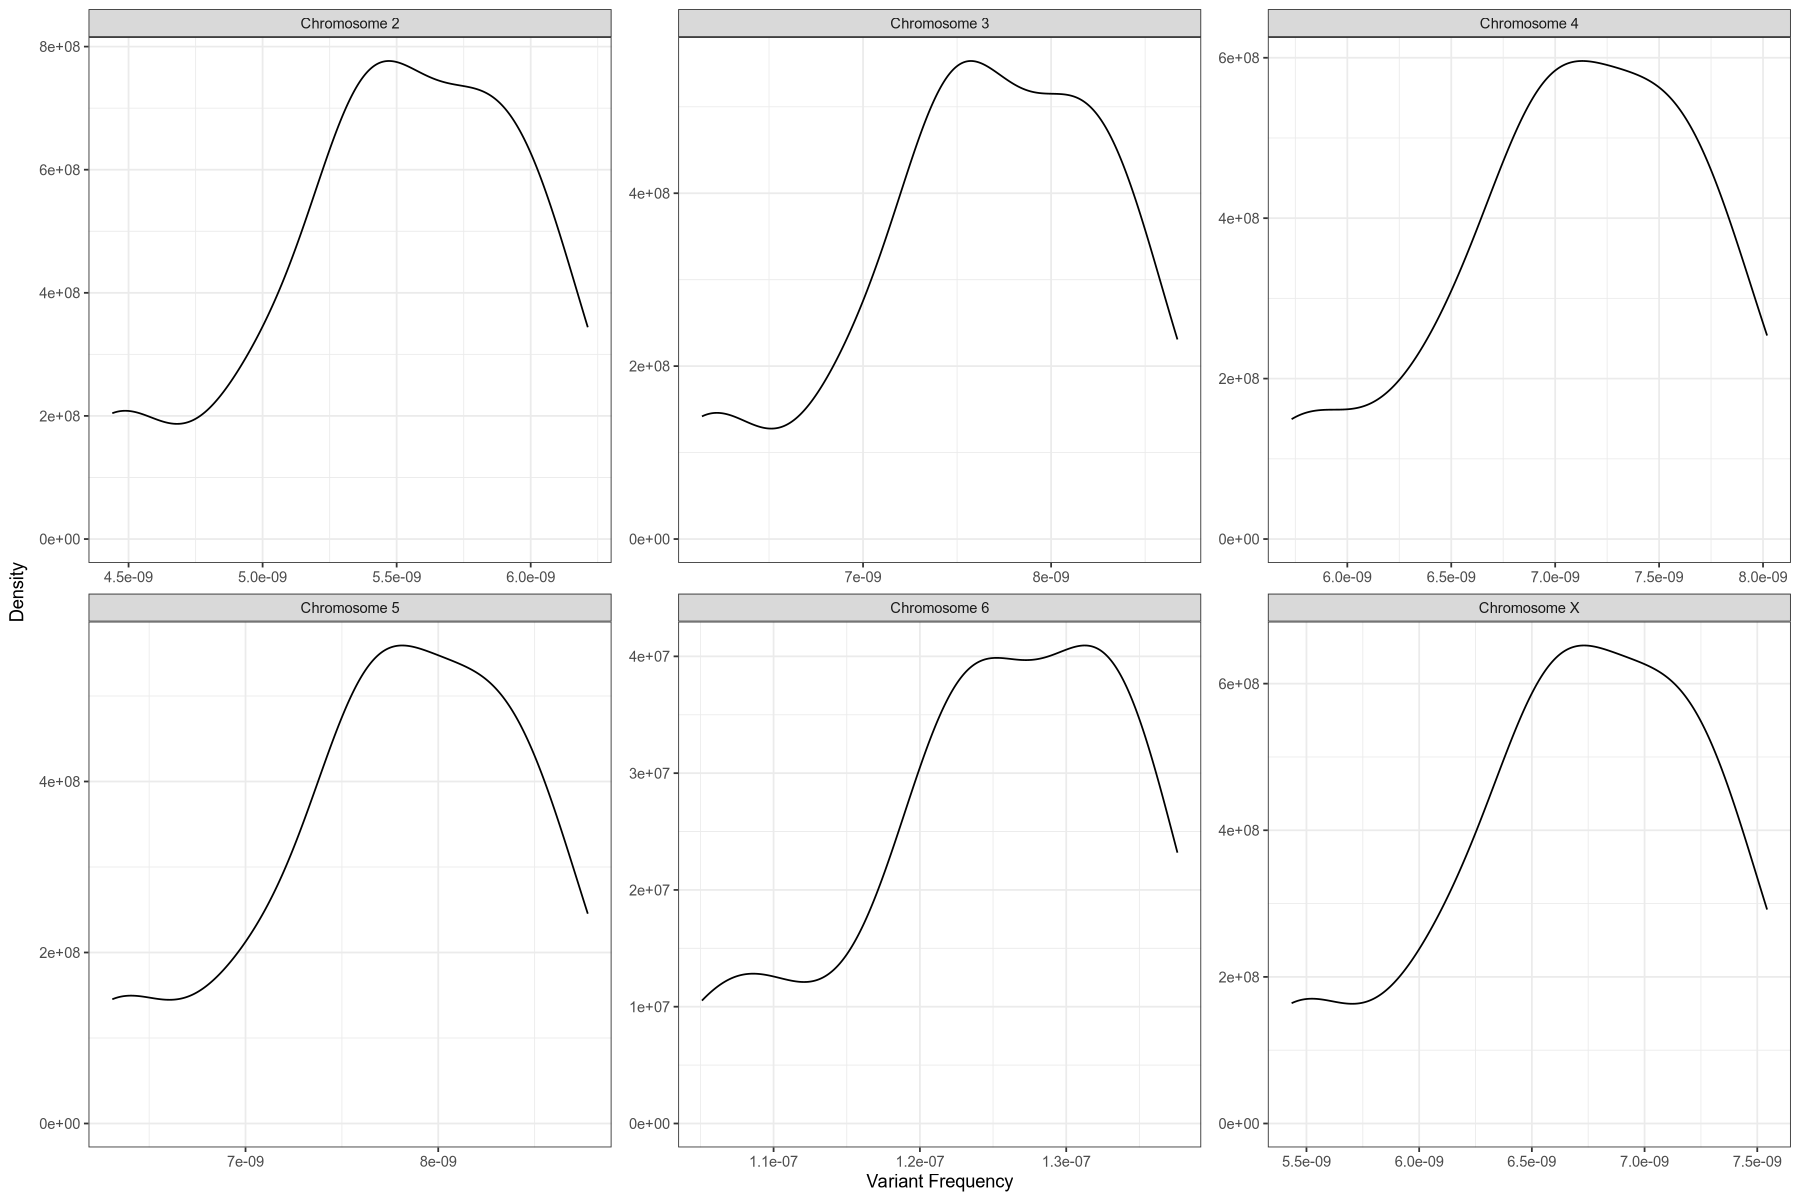

In [77]:
## look at the distribution of the allele frequency data
chr_allele_frequency <- chr_strain_alleles %>%
    # filter(number_chrom != "Chr_6") %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = allele_per_bp)) +
        geom_density() +
        labs(x = "Variant Frequency", y = "Density") +
        theme_bw() +
        facet_wrap(~number_chrom, scales = "free")
chr_allele_frequency

In [78]:
## test to see if the data is normally distributed
shapiro.test(chr_strain_alleles$allele_per_bp)


	Shapiro-Wilk normality test

data:  chr_strain_alleles$allele_per_bp
W = 0.48401, p-value < 2.2e-16


In [79]:
## filter for only the autosomes
autosome_strain_alleles <- chr_strain_alleles %>%
    filter(number_chrom != "Chr_6")

## test to see if the data is normally distributed
shapiro.test(autosome_strain_alleles$allele_per_bp)


	Shapiro-Wilk normality test

data:  autosome_strain_alleles$allele_per_bp
W = 0.97441, p-value = 0.0485


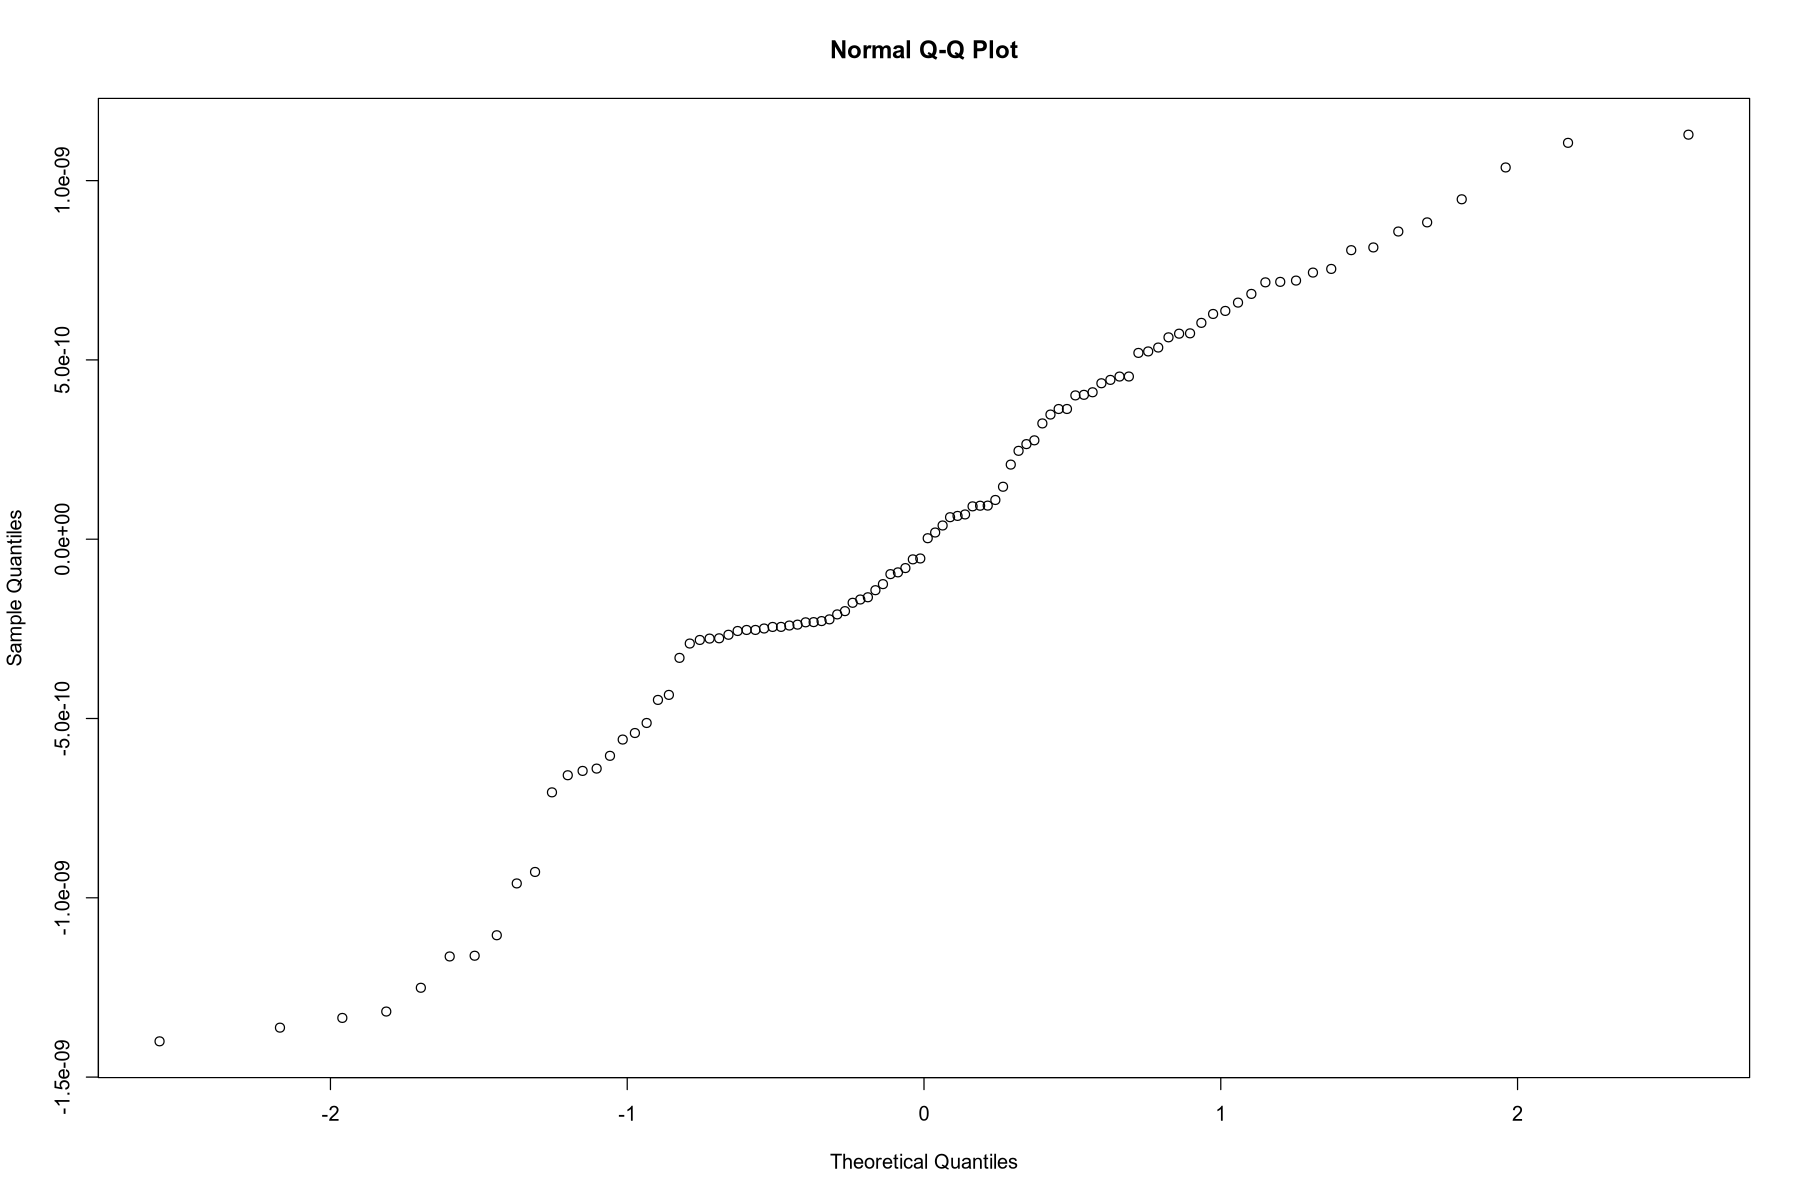

In [80]:
## calculate the relationship between allele frequency and chromosome
fusion_chrom_lm <- lm(allele_per_bp ~ number_chrom + status, data = autosome_strain_alleles)
qqnorm(fusion_chrom_lm$residuals)

In [81]:
## add latitude data to variant frequency information
autosome_strain_lat <- metadata %>%
    select(strain, latitude) %>%
    inner_join(autosome_strain_alleles, by = "strain")

## calculate the relationship between allele frequency and chromosome for the autosomes
fusion_chrom_lm <- lm(allele_per_bp ~ number_chrom*status + status*latitude, data = autosome_strain_lat)
summary(fusion_chrom_lm)


Call:
lm(formula = allele_per_bp ~ number_chrom * status + status * 
    latitude, data = autosome_strain_lat)

Residuals:
       Min         1Q     Median         3Q        Max 
-1.393e-09 -2.716e-10  7.930e-12  4.058e-10  1.137e-09 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      5.296e-09  1.085e-09   4.880 4.69e-06 ***
number_chromChr_3                2.126e-09  2.380e-10   8.933 5.64e-14 ***
number_chromChr_4                1.556e-09  2.380e-10   6.539 3.93e-09 ***
number_chromChr_5                2.241e-09  2.380e-10   9.413 5.78e-15 ***
number_chromChr_X                1.183e-09  2.380e-10   4.969 3.28e-06 ***
statusUnfused                   -8.943e-10  1.627e-09  -0.550    0.584    
latitude                         3.078e-12  2.729e-11   0.113    0.910    
number_chromChr_3:statusUnfused  6.033e-11  4.346e-10   0.139    0.890    
number_chromChr_4:statusUnfused  9.064e-11  4.346e-10   0.209    0.835    

In [82]:
## perform an ANOVA to look at the difference in expression between chromosomes
fusion_chrom_anova <- aov(allele_per_bp ~ number_chrom*status + status*latitude, data = autosome_strain_lat)
summary(fusion_chrom_anova)

                    Df    Sum Sq   Mean Sq F value Pr(>F)    
number_chrom         4 6.682e-17 1.670e-17  42.121 <2e-16 ***
status               1 1.510e-18 1.505e-18   3.796 0.0546 .  
latitude             1 2.100e-19 2.150e-19   0.541 0.4639    
number_chrom:status  4 3.000e-20 7.000e-21   0.017 0.9994    
status:latitude      1 2.100e-19 2.130e-19   0.538 0.4653    
Residuals           88 3.490e-17 3.970e-19                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [83]:
## perform post hoc test and figure out which chromosome(s) are driving this interaction
fusion_chrom_anova <- aov(allele_per_bp ~ number_chrom, data = autosome_strain_lat)
fusion_chrom_tukey <- TukeyHSD(fusion_chrom_anova)

## assign letters to the groups
groups <- multcompLetters4(fusion_chrom_anova, fusion_chrom_tukey)
fusion_chrom_groups <- groups$number_chrom %>%
    as.data.frame.list() %>%
    select(Letters) %>%
    rownames_to_column("number_chrom") %>%
    full_join(autosome_strain_lat, by = "number_chrom")
head(fusion_chrom_groups)

,number_chrom,Letters,strain,latitude,status,allele,count,size_bp,chromosome_sites,allele_per_bp
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,Chr_5,a,BB_05_18,36.46119,Fused,54310,112160,27587546,6.188438e+12,8.776043e-09
2,Chr_5,a,FG_06_22,30.70849,Unfused,49748,112657,27587546,6.215860e+12,8.003397e-09
3,Chr_5,a,FP_10_18,34.18866,Unfused,47241,111099,27587546,6.129898e+12,7.706654e-09
4,Chr_5,a,HI_99_20,38.66367,Fused,42309,110099,27587546,6.074722e+12,6.964763e-09
5,Chr_5,a,IR_04_34,41.77932,Fused,45318,110669,27587546,6.106172e+12,7.421671e-09
6,Chr_5,a,LA_99_52,36.27057,Unfused,46828,110433,27587546,6.093151e+12,7.685350e-09


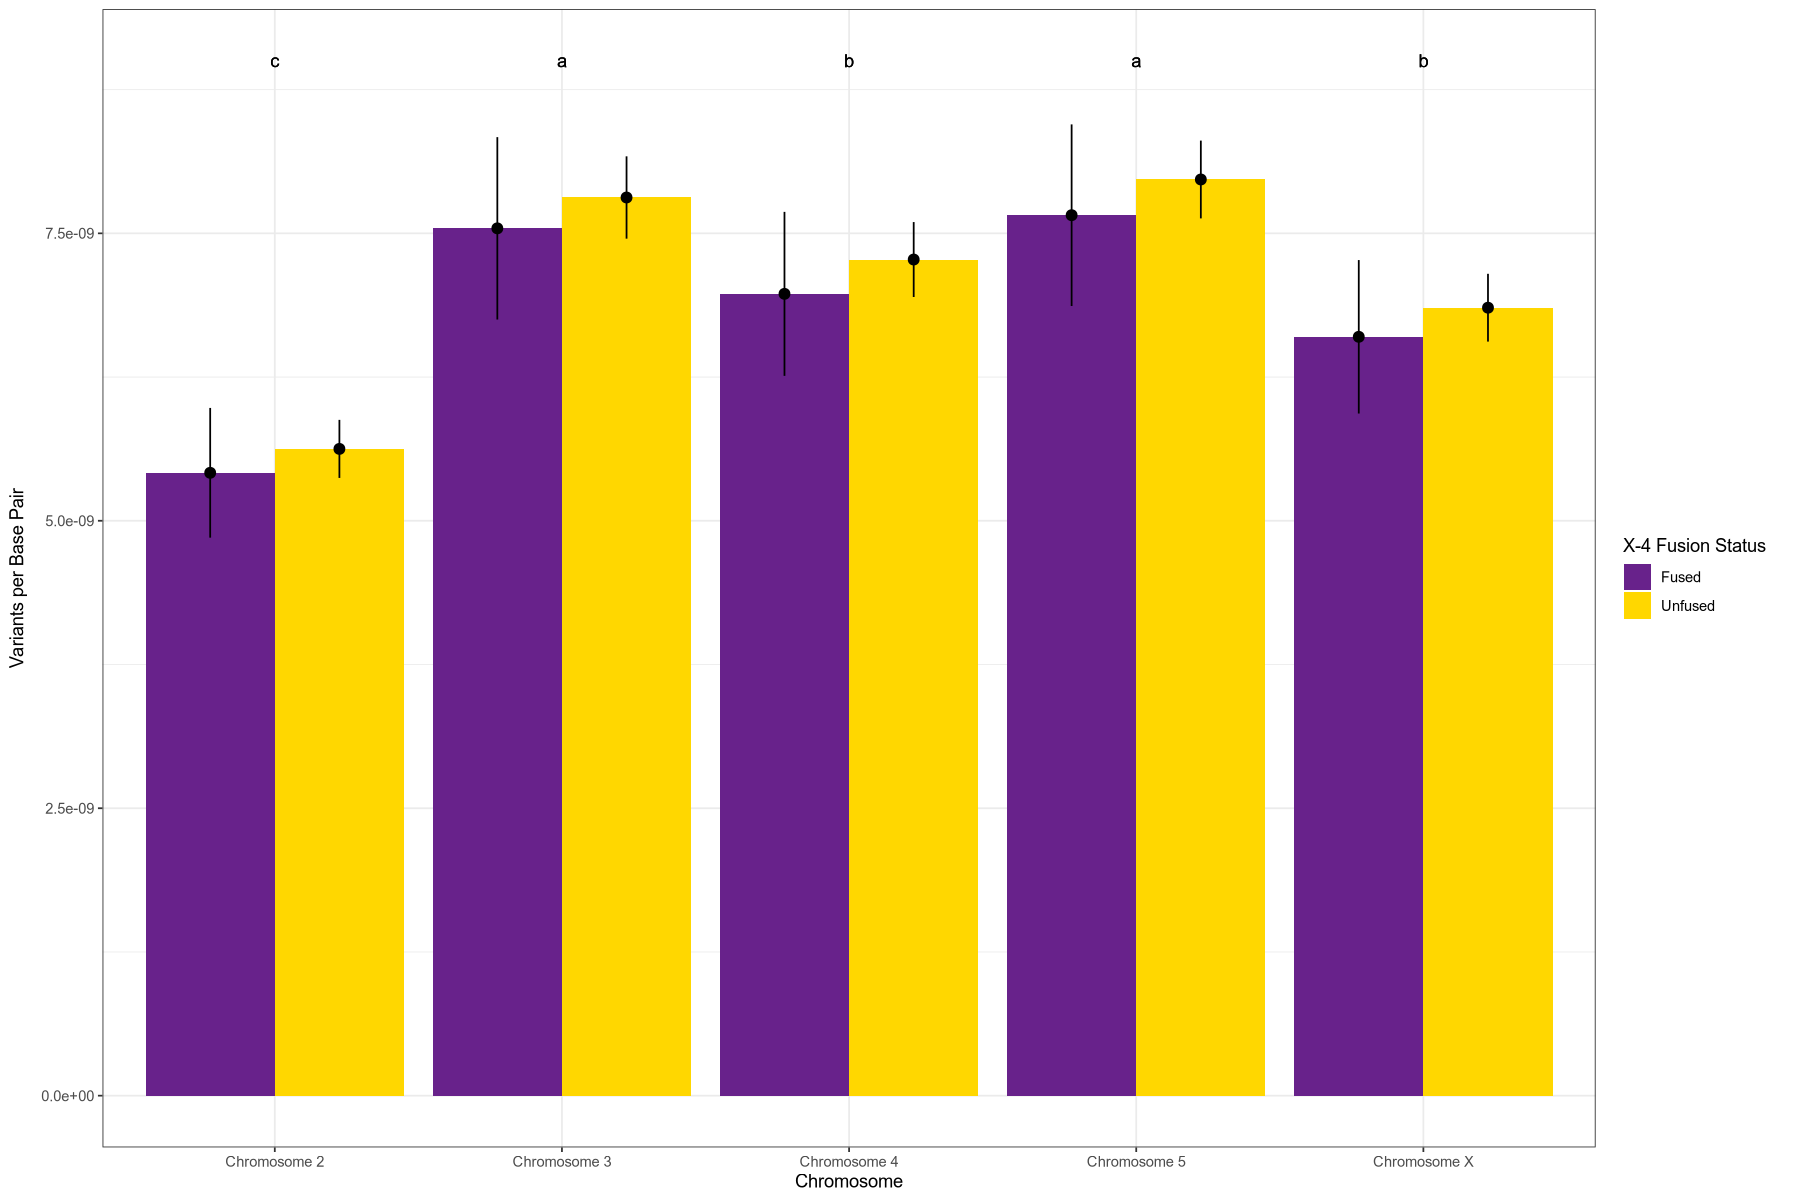

In [84]:
## create data frame for bar plot
fusion_chrom_df <- fusion_chrom_groups %>%
    group_by(number_chrom, Letters, status) %>%
    reframe(sd = sd(allele_per_bp),
            avg = mean(allele_per_bp))

## plot bar plot
fusion_variant_box <- fusion_chrom_df %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom)) +
        geom_bar(aes(y = avg, fill = status), stat = "identity", position = position_dodge()) +
        geom_pointrange(aes(y = avg, fill = status, ymin = avg-sd, ymax = avg+sd), position = position_dodge(0.9), show.legend = FALSE) +
        geom_text(aes(y = 0.000000009, label = Letters)) +
        labs(x = "Chromosome", y = "Variants per Base Pair", fill = "X-4 Fusion Status") +
        scale_fill_manual(values = c("darkorchid4", "gold")) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_variant_box

In [85]:
ggsave("figures/neoY/variant_by_fusion.png", fusion_variant_box, height = 6, width = 8)

#### Count alleles for each high impact type

In [86]:
## get the number of alleles in each strain for each potential impact
chr_effect_only <- snpeff_high %>%
    select(number_chrom, id, annotation_impact) %>%
    unique() %>%
    right_join(snps, by = c("number_chrom", "id"), relationship = "many-to-many") %>%
    mutate(genotype = case_when(genotype == "1/1" ~ 2,
                                genotype == "0/1" | genotype == "1/0" ~ 1,
                                genotype == "0/0" ~ 0)) %>%
    inner_join(fusion, by = "strain") %>%
    mutate(annotation_impact = case_when(is.na(annotation_impact) ~ "none",
                                         TRUE ~ annotation_impact)) %>%
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    mutate_all(replace_na, 0) %>%
    group_by(number_chrom, status, strain, annotation_impact) %>%
    reframe(allele = sum(genotype)) %>%
    pivot_wider(names_from = annotation_impact, values_from = allele) %>%
    mutate(across(!c(number_chrom, status, strain), ~replace_na(., 0)))

## calculate the frequency of variant impact per allele
chr_fusion_effect <- chr_fusion_allele_only %>%
    select(-count) %>%
    full_join(chr_effect_only, by = c("number_chrom", "status", "strain")) %>%
    filter(number_chrom != "Chr_6")

head(chr_fusion_effect)

number_chrom,status,strain,allele,3_prime_UTR_variant,5_prime_UTR_variant,bidirectional_gene_fusion,conservative_inframe_deletion,conservative_inframe_insertion,disruptive_inframe_deletion,⋯,splice_donor_variant,splice_region_variant,start_lost,stop_gained,stop_lost,synonymous_variant,transcript_ablation,missense_variant,feature_ablation,stop_retained_variant
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Chr_2,Fused,BB_05_18,61548,0,0,0,3,0,6,⋯,8,9,1,74,53,5,2,0,0,0
Chr_2,Fused,HI_99_20,48402,1,0,1,3,0,2,⋯,7,10,2,51,61,3,2,0,0,0
Chr_2,Fused,IR_04_34,51097,1,0,1,2,0,0,⋯,7,8,2,53,43,1,2,0,0,0
Chr_2,Fused,LR_10_32,51847,1,2,1,2,0,1,⋯,15,11,0,59,43,1,2,0,0,0
Chr_2,Fused,MK_07_164,42793,1,0,0,1,2,2,⋯,8,6,2,51,42,1,2,0,0,0
Chr_2,Fused,MK_10_52,53884,0,0,1,1,0,2,⋯,4,11,1,64,37,1,2,0,0,0


In [87]:
unique(snpeff_high$annotation_impact)

[1] "frameshift_variant"                 "splice_donor_variant"              
 [3] "intron_variant"                     "stop_gained"                       
 [5] "stop_lost"                          "disruptive_inframe_insertion"      
 [7] "splice_region_variant"              "splice_acceptor_variant"           
 [9] "start_lost"                         "missense_variant"                  
[11] "conservative_inframe_insertion"     "synonymous_variant"                
[13] "non_coding_transcript_exon_variant" "gene_fusion"                       
[15] "disruptive_inframe_deletion"        "conservative_inframe_deletion"     
[17] "5_prime_UTR_variant"                "bidirectional_gene_fusion"         
[19] "stop_retained_variant"              "transcript_ablation"               
[21] "feature_ablation"                   "exon_loss_variant"                 
[23] "3_prime_UTR_truncation"             "3_prime_UTR_variant"               
[25] "5_prime_UTR_truncation"             "chromosome_number_variation"

### Calculate difference in nonsense SNPs per chromosome, normalizing for number of overall SNPs, based on fusion status

In [88]:
## combine the start lost and stop gained effects to count total nonsense mutations
chr_fusion_nonsense <- chr_fusion_effect %>%
    pivot_longer(c(stop_gained, start_lost), names_to = "effect", values_to = "value") %>%
    group_by(number_chrom, status, strain, allele) %>%
    reframe(nonsense = sum(value)) %>%
    mutate(nonsense_ratio = nonsense/allele)

## perform an ANOVA to look at the difference in expression between chromosomes
fusion_chrom_nonsense_anova <- aov(nonsense_ratio ~ number_chrom*status, data = chr_fusion_nonsense)
summary(fusion_chrom_nonsense_anova)

                    Df    Sum Sq   Mean Sq F value Pr(>F)    
number_chrom         4 2.723e-05 6.808e-06 408.292 <2e-16 ***
status               1 1.300e-08 1.300e-08   0.756 0.3868    
number_chrom:status  4 2.090e-07 5.200e-08   3.136 0.0183 *  
Residuals           90 1.501e-06 1.700e-08                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [89]:
## perform post hoc test and figure out which chromosome(s) are driving this interaction
fusion_chrom_nonsense_tukey <- TukeyHSD(fusion_chrom_nonsense_anova)

## assign letters to the groups
groups <- multcompLetters4(fusion_chrom_nonsense_anova, fusion_chrom_nonsense_tukey)
fusion_chrom_nonsense_groups <- groups$`number_chrom:status` %>%
    as.data.frame.list() %>%
    select(Letters) %>%
    rownames_to_column("id") %>%
    separate_wider_delim(id, delim = ":", names = c("number_chrom", "status")) %>%
    full_join(chr_fusion_nonsense, by = c("number_chrom", "status"))
head(fusion_chrom_nonsense_groups)

number_chrom,status,Letters,strain,allele,nonsense,nonsense_ratio
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Chr_5,Fused,a,BB_05_18,54310,114,0.002099061
Chr_5,Fused,a,HI_99_20,42309,68,0.001607223
Chr_5,Fused,a,IR_04_34,45318,103,0.002272828
Chr_5,Fused,a,LR_10_32,45402,92,0.002026342
Chr_5,Fused,a,MK_07_164,37798,83,0.002195883
Chr_5,Fused,a,MK_10_52,47553,103,0.002166004


Warning message in geom_text(aes(y = 0.0025, label = Letters, fill = status), position = position_dodge(0.9), :
“Ignoring unknown aesthetics: fill”


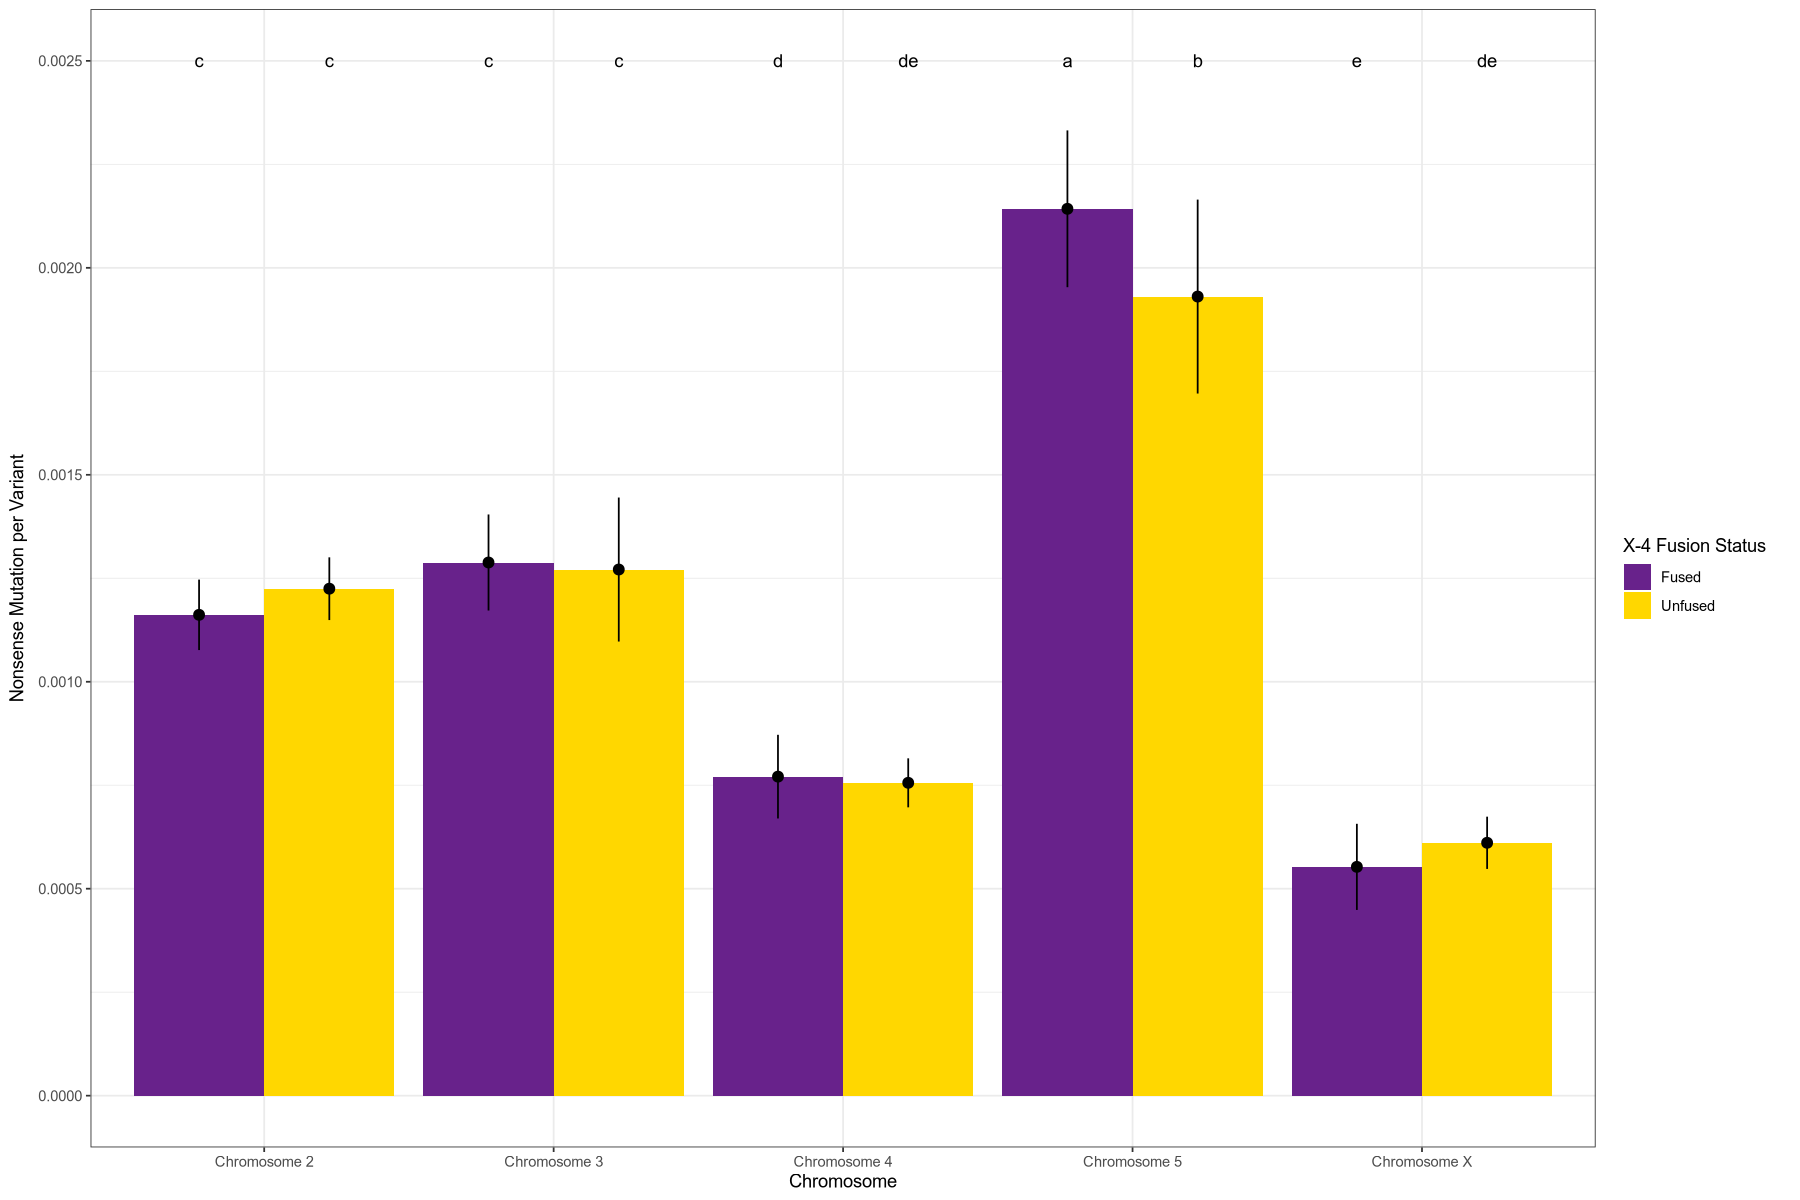

In [90]:
## create data frame for bar plot
fusion_chrom_nonsense_df <- fusion_chrom_nonsense_groups %>%
    group_by(number_chrom, Letters, status) %>%
    reframe(sd = sd(nonsense_ratio),
            avg = mean(nonsense_ratio))

## plot bar plot
fusion_nonsense_box <- fusion_chrom_nonsense_df %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom)) +
        geom_bar(aes(y = avg, fill = status), stat = "identity", position = position_dodge()) +
        geom_pointrange(aes(y = avg, fill = status, ymin = avg-sd, ymax = avg+sd), position = position_dodge(0.9), show.legend = FALSE) +
        geom_text(aes(y = 0.0025, label = Letters, fill = status), position = position_dodge(0.9), show.legend = FALSE) +
        labs(x = "Chromosome", y = "Nonsense Mutation per Variant", fill = "X-4 Fusion Status") +
        scale_fill_manual(values = c("darkorchid4", "gold")) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_nonsense_box

In [91]:
ggsave("figures/neoY/nonsense_by_fusion.png", fusion_nonsense_box, height = 6, width = 8)

### Calculate difference in missense SNPs per chromosome, normalizing for number of overall SNPs, based on fusion status

In [92]:
## select for only the missense alleles
chr_fusion_missense <- chr_fusion_effect %>%
    select(number_chrom, status, strain, allele, missense_variant) %>%
    mutate(missense_ratio = missense_variant/allele)

## perform a Kruskal Wallis test to look at the difference in expression between chromosomes
kruskal.test(missense_ratio ~ number_chrom, data = chr_fusion_missense)


	Kruskal-Wallis rank sum test

data:  missense_ratio by number_chrom
Kruskal-Wallis chi-squared = 54.282, df = 4, p-value = 4.593e-11


In [93]:
## perform a Kruskal Wallis test to look at the difference in expression based on fusion status
kruskal.test(missense_ratio ~ status, data = chr_fusion_missense)


	Kruskal-Wallis rank sum test

data:  missense_ratio by status
Kruskal-Wallis chi-squared = 0.14547, df = 1, p-value = 0.7029


In [94]:
## perform a post hoc test on the chromosome analysis
pairwise.wilcox.test(chr_fusion_missense$missense_ratio, chr_fusion_missense$number_chrom, p.adjust.method = "BH")

Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”


Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  chr_fusion_missense$missense_ratio and chr_fusion_missense$number_chrom 

      Chr_2   Chr_3   Chr_4   Chr_5  
Chr_3 3.0e-07 -       -       -      
Chr_4 0.00133 2.3e-06 -       -      
Chr_5 1.1e-05 0.20286 0.00064 -      
Chr_X 5.1e-05 3.9e-05 0.20286 0.01149

P value adjustment method: BH 

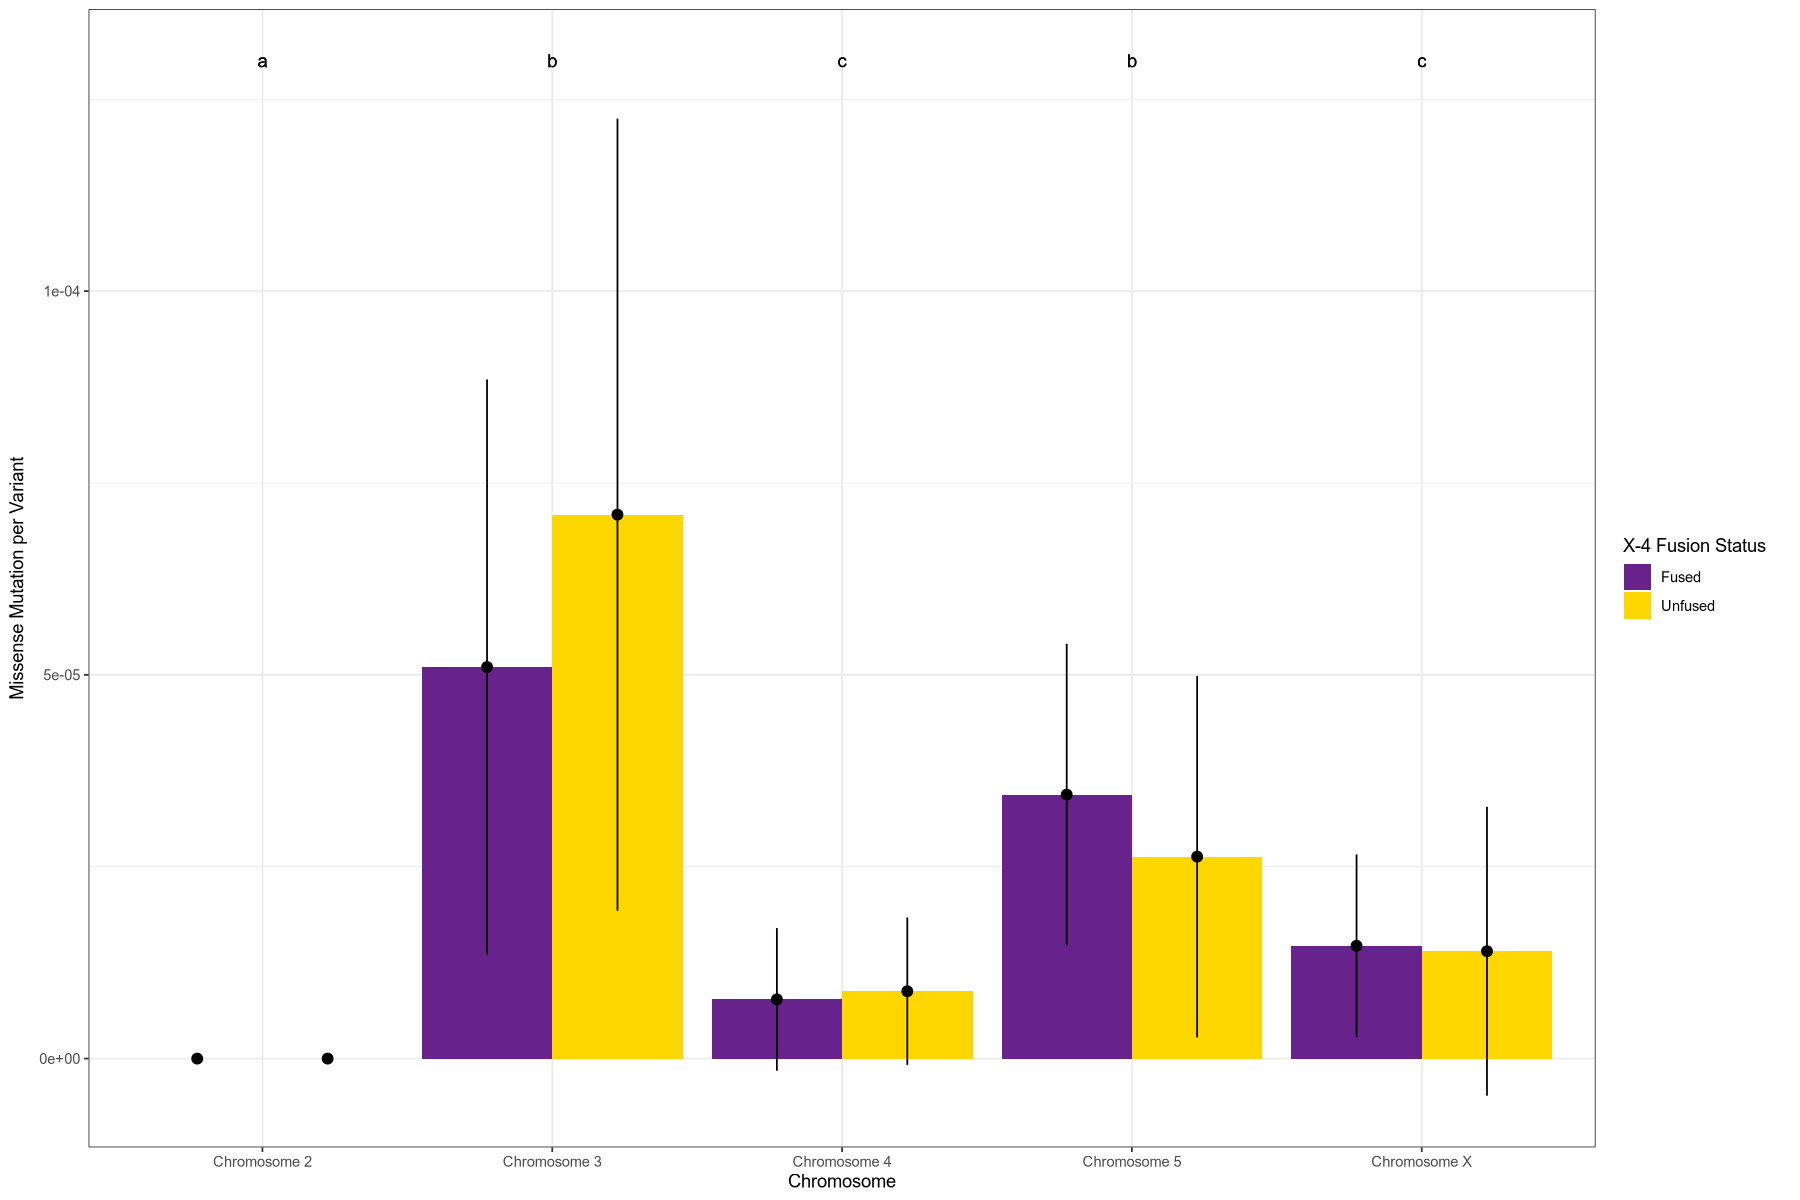

In [95]:
## create data frame for bar plot
fusion_chrom_missense_df <- chr_fusion_missense %>%
    mutate(Letters = case_when(number_chrom == "Chr_2" ~ "a",
                               number_chrom == "Chr_3" ~ "b",
                               number_chrom == "Chr_4" ~ "c",
                               number_chrom == "Chr_5" ~ "b",
                               number_chrom == "Chr_X" ~ "c")) %>%
    group_by(number_chrom, Letters, status) %>%
    reframe(sd = sd(missense_ratio),
            avg = mean(missense_ratio))

## plot bar plot
fusion_missense_box <- fusion_chrom_missense_df %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom)) +
        geom_bar(aes(y = avg, fill = status), stat = "identity", position = position_dodge()) +
        geom_pointrange(aes(y = avg, fill = status, ymin = avg-sd, ymax = avg+sd), position = position_dodge(0.9), show.legend = FALSE) +
        geom_text(aes(y = 0.00013, label = Letters)) +
        labs(x = "Chromosome", y = "Missense Mutation per Variant", fill = "X-4 Fusion Status") +
        scale_fill_manual(values = c("darkorchid4", "gold")) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_missense_box

In [96]:
ggsave("figures/neoY/missense_by_fusion.png", fusion_missense_box, height = 6, width = 8)

### Calculate difference in frameshifts per chromosome, normalizing for number of overall SNPs, based on fusion status

In [97]:
## select for only the frameshift alleles
chr_fusion_frameshift <- chr_fusion_effect %>%
    select(number_chrom, status, strain, allele, frameshift_variant) %>%
    mutate(frameshift_ratio = frameshift_variant/allele)

## perform a Kruskal Wallis test to determine if there is a difference in frameshift frequency by chromosome
kruskal.test(frameshift_ratio ~ number_chrom, data = chr_fusion_frameshift)


	Kruskal-Wallis rank sum test

data:  frameshift_ratio by number_chrom
Kruskal-Wallis chi-squared = 85.917, df = 4, p-value < 2.2e-16


In [98]:
## perform a Kruskal Wallis test to determine if there is a difference in frameshift frequency by chromosome
kruskal.test(frameshift_ratio ~ status, data = chr_fusion_frameshift)


	Kruskal-Wallis rank sum test

data:  frameshift_ratio by status
Kruskal-Wallis chi-squared = 0.0068458, df = 1, p-value = 0.9341


In [99]:
## perform a post hoc test on the chromosome analysis
pairwise.wilcox.test(chr_fusion_frameshift$frameshift_ratio, chr_fusion_frameshift$number_chrom, p.adjust.method = "BH")


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  chr_fusion_frameshift$frameshift_ratio and chr_fusion_frameshift$number_chrom 

      Chr_2   Chr_3   Chr_4   Chr_5  
Chr_3 0.11    -       -       -      
Chr_4 2.1e-11 2.1e-11 -       -      
Chr_5 2.1e-11 7.3e-11 2.1e-11 -      
Chr_X 2.1e-11 2.1e-11 0.56    2.1e-11

P value adjustment method: BH 

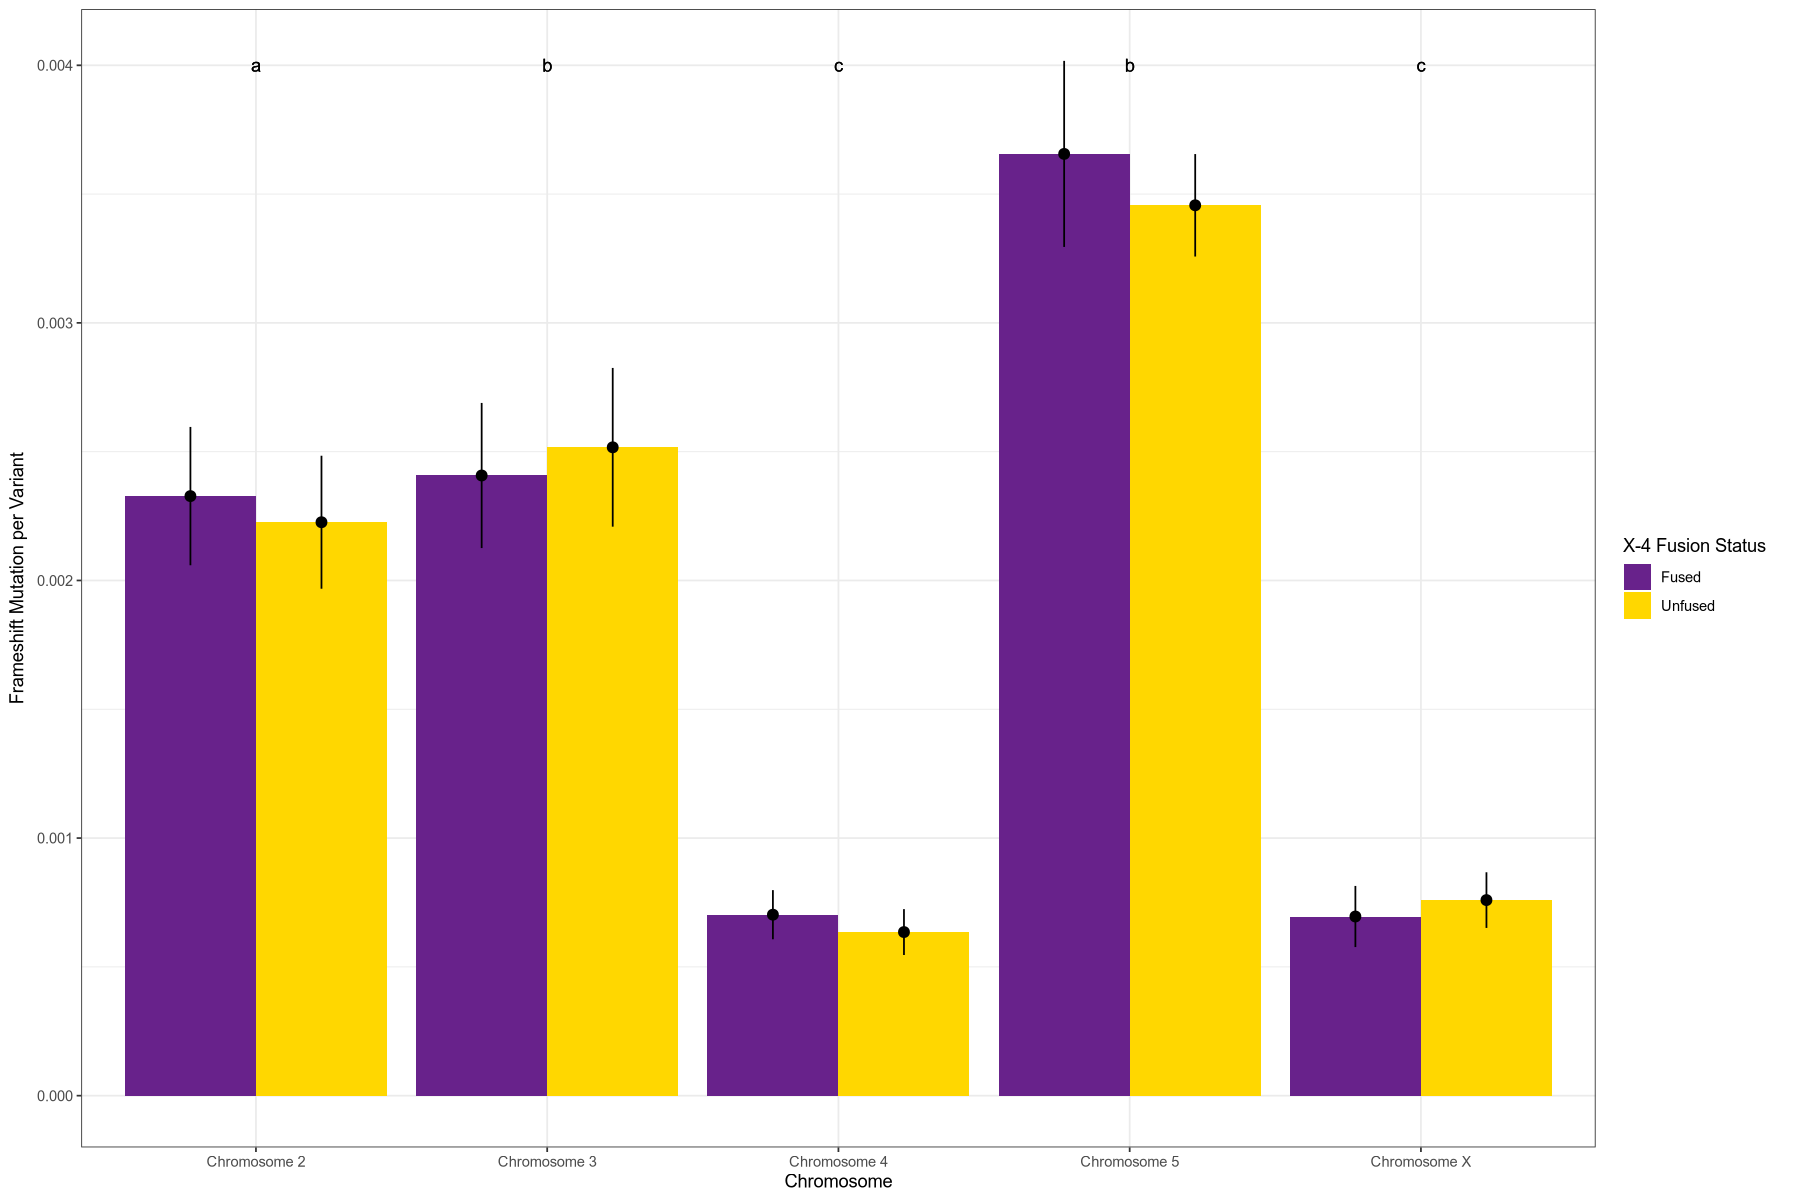

In [100]:
## create data frame for bar plot
fusion_chrom_frameshift_df <- chr_fusion_frameshift %>%
    mutate(Letters = case_when(number_chrom == "Chr_2" ~ "a",
                               number_chrom == "Chr_3" ~ "b",
                               number_chrom == "Chr_4" ~ "c",
                               number_chrom == "Chr_5" ~ "b",
                               number_chrom == "Chr_X" ~ "c")) %>%
    group_by(number_chrom, Letters, status) %>%
    reframe(sd = sd(frameshift_ratio),
            avg = mean(frameshift_ratio))

## plot bar plot
fusion_frameshift_box <- fusion_chrom_frameshift_df %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom)) +
        geom_bar(aes(y = avg, fill = status), stat = "identity", position = position_dodge()) +
        geom_pointrange(aes(y = avg, fill = status, ymin = avg-sd, ymax = avg+sd), position = position_dodge(0.9), show.legend = FALSE) +
        geom_text(aes(y = 0.004, label = Letters)) +
        labs(x = "Chromosome", y = "Frameshift Mutation per Variant", fill = "X-4 Fusion Status") +
        scale_fill_manual(values = c("darkorchid4", "gold")) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_frameshift_box

In [101]:
ggsave("figures/neoY/frameshift_by_fusion.png", fusion_frameshift_box, height = 6, width = 8)

### Calculate difference in deleterious frameshifts per chromosome, normalizing for total number of frameshifts, based on fusion status

In [102]:
## combine the InDel information by the effect
chr_fusion_frameshift_effect <- chr_fusion_effect %>%
    pivot_longer(c(conservative_inframe_insertion, conservative_inframe_deletion), names_to = "conservative_effect", values_to = "conservative") %>%
    pivot_longer(c(disruptive_inframe_insertion, disruptive_inframe_deletion), names_to = "disruptive_effect", values_to = "disruptive") %>%
    group_by(number_chrom, status, strain, allele) %>%
    reframe(conservative = sum(conservative),
            disruptive = sum(disruptive)) %>%
    mutate(frameshift_ratio = case_when(conservative < 1 ~ disruptive,
                             TRUE ~ disruptive/conservative))

## perform a Kruskal Wallis test to determine if there is a difference in frameshift frequency by chromosome
kruskal.test(frameshift_ratio ~ number_chrom, data = chr_fusion_frameshift_effect)


	Kruskal-Wallis rank sum test

data:  frameshift_ratio by number_chrom
Kruskal-Wallis chi-squared = 54.102, df = 4, p-value = 5.009e-11


In [103]:
## perform a Kruskal Wallis test to determine if there is a difference in frameshift frequency by chromosome
kruskal.test(frameshift_ratio ~ status, data = chr_fusion_frameshift_effect)


	Kruskal-Wallis rank sum test

data:  frameshift_ratio by status
Kruskal-Wallis chi-squared = 0.038303, df = 1, p-value = 0.8448


In [104]:
## perform a post hoc test on the chromosome analysis
pairwise.wilcox.test(chr_fusion_frameshift_effect$frameshift_ratio, chr_fusion_frameshift_effect$number_chrom, p.adjust.method = "BH")

Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”


Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  chr_fusion_frameshift_effect$frameshift_ratio and chr_fusion_frameshift_effect$number_chrom 

      Chr_2   Chr_3   Chr_4   Chr_5  
Chr_3 2.0e-05 -       -       -      
Chr_4 0.00058 0.28906 -       -      
Chr_5 2.0e-05 0.88142 0.28906 -      
Chr_X 0.28906 1.2e-06 5.2e-06 1.2e-06

P value adjustment method: BH 

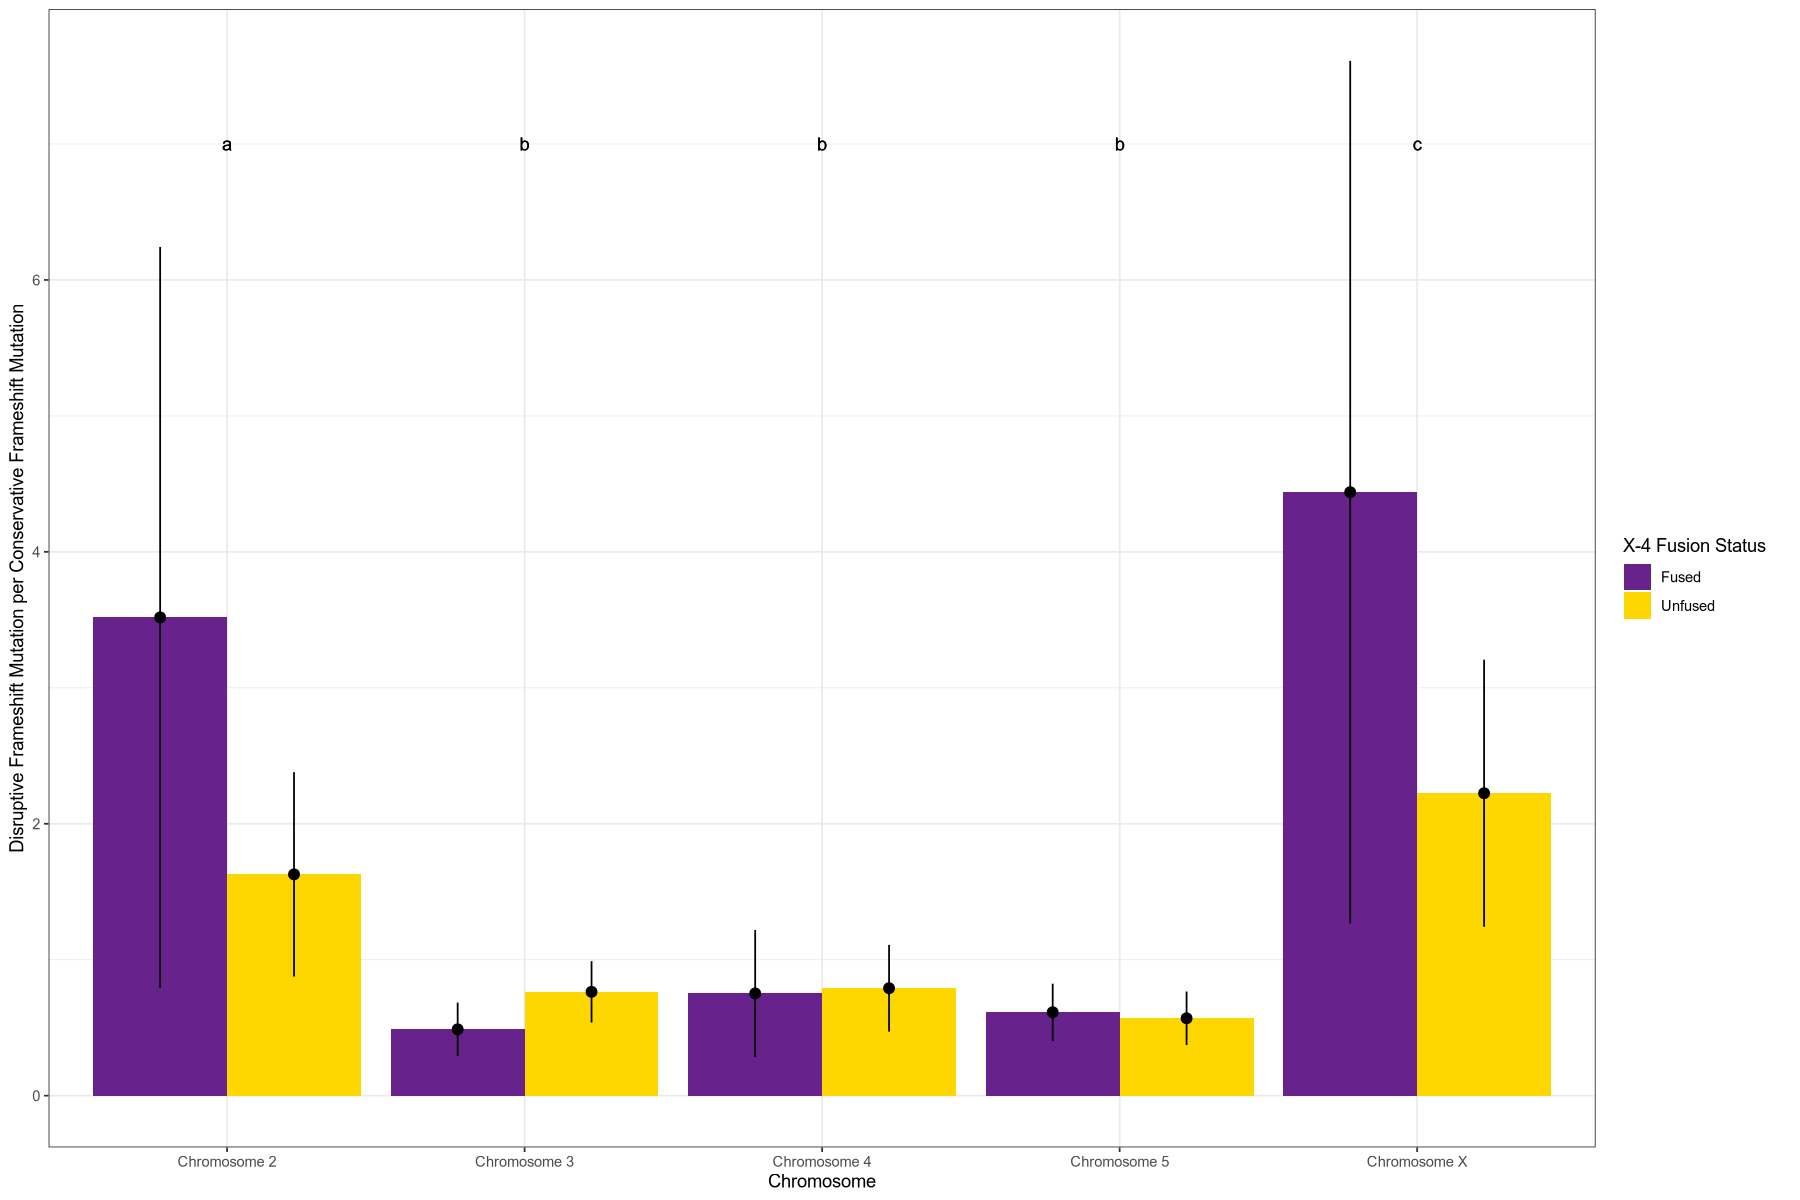

In [105]:
## create data frame for bar plot
fusion_chrom_frameshift_effect_df <- chr_fusion_frameshift_effect %>%
    mutate(Letters = case_when(number_chrom == "Chr_2" ~ "a",
                               number_chrom == "Chr_3" ~ "b",
                               number_chrom == "Chr_4" ~ "b",
                               number_chrom == "Chr_5" ~ "b",
                               number_chrom == "Chr_X" ~ "c")) %>%
    group_by(number_chrom, Letters, status) %>%
    reframe(sd = sd(frameshift_ratio),
            avg = mean(frameshift_ratio))

## plot bar plot
fusion_frameshift_effect_box <- fusion_chrom_frameshift_effect_df %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom)) +
        geom_bar(aes(y = avg, fill = status), stat = "identity", position = position_dodge()) +
        geom_pointrange(aes(y = avg, fill = status, ymin = avg-sd, ymax = avg+sd), position = position_dodge(0.9), show.legend = FALSE) +
        geom_text(aes(y = 7, label = Letters)) +
        labs(x = "Chromosome", y = "Disruptive Frameshift Mutation per Conservative Frameshift Mutation", fill = "X-4 Fusion Status") +
        scale_fill_manual(values = c("darkorchid4", "gold")) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_frameshift_effect_box

In [106]:
ggsave("figures/neoY/frameshift_effect_by_fusion.png", fusion_frameshift_effect_box, height = 6, width = 8)

### Calculate difference in introns per chromosome, normalizing for number of overall SNPs, based on fusion status

In [107]:
## select for only the intron alleles
chr_fusion_intron <- chr_fusion_effect %>%
    select(number_chrom, status, strain, allele, intron_variant) %>%
    mutate(intron_ratio = intron_variant/allele)

## perform an ANOVA to look at the difference in expression between chromosomes
fusion_chrom_intron_anova <- aov(intron_ratio ~ number_chrom*status, data = chr_fusion_intron)
summary(fusion_chrom_intron_anova)

                    Df    Sum Sq   Mean Sq F value Pr(>F)    
number_chrom         4 1.329e-06 3.324e-07  68.047 <2e-16 ***
status               1 0.000e+00 0.000e+00   0.000  0.994    
number_chrom:status  4 2.390e-08 6.000e-09   1.224  0.306    
Residuals           90 4.396e-07 4.900e-09                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [108]:
## perform post hoc test and figure out which chromosome(s) are driving this interaction
fusion_chrom_intron_tukey <- TukeyHSD(fusion_chrom_intron_anova)

## assign letters to the groups
groups <- multcompLetters4(fusion_chrom_intron_anova, fusion_chrom_intron_tukey)
fusion_chrom_intron_groups <- groups$number_chrom %>%
    as.data.frame.list() %>%
    select(Letters) %>%
    rownames_to_column("id") %>%
    separate_wider_delim(id, delim = ":", names = "number_chrom") %>%
    full_join(chr_fusion_intron, by = "number_chrom")
head(fusion_chrom_intron_groups)

number_chrom,Letters,status,strain,allele,intron_variant,intron_ratio
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Chr_5,a,Fused,BB_05_18,54310,25,0.0004603204
Chr_5,a,Fused,HI_99_20,42309,24,0.0005672552
Chr_5,a,Fused,IR_04_34,45318,20,0.0004413257
Chr_5,a,Fused,LR_10_32,45402,19,0.0004184838
Chr_5,a,Fused,MK_07_164,37798,16,0.0004233028
Chr_5,a,Fused,MK_10_52,47553,21,0.0004416125


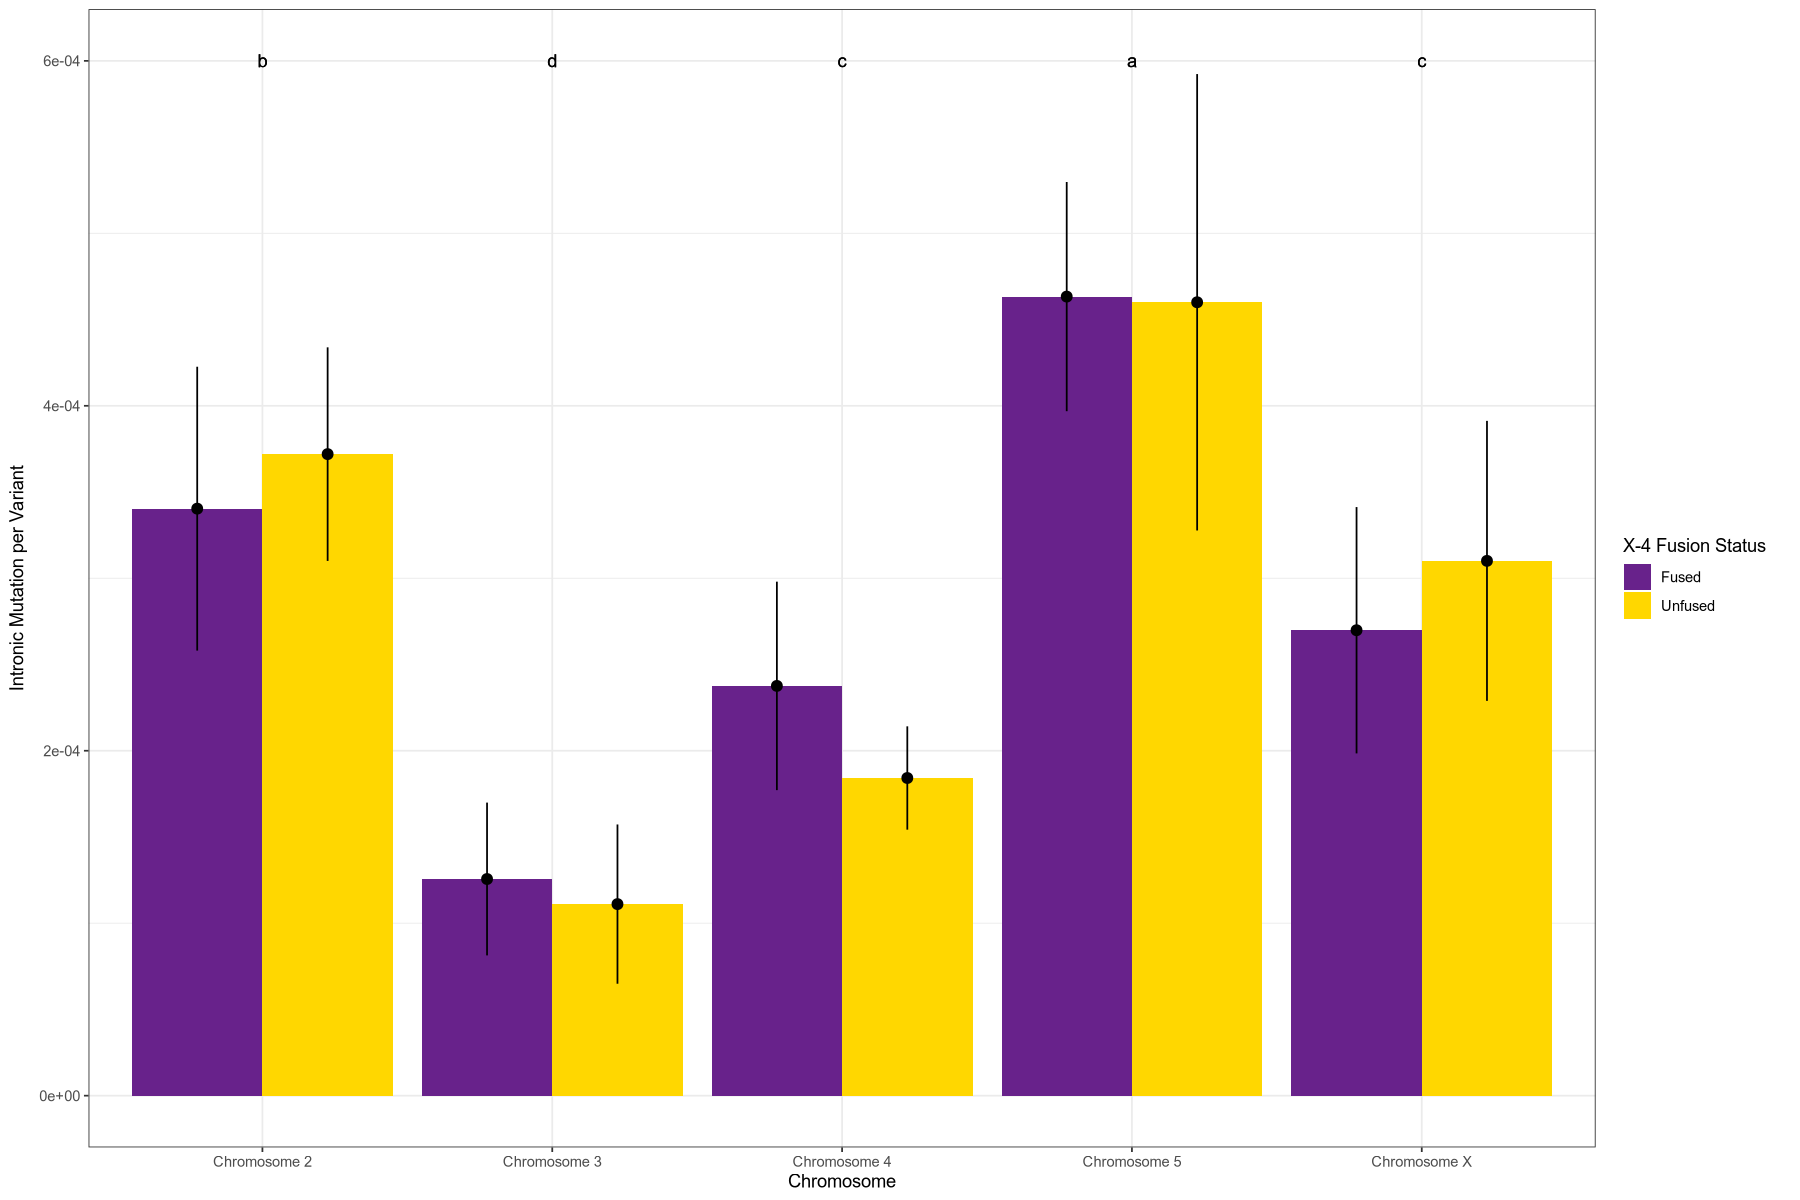

In [109]:
## create data frame for bar plot
fusion_chrom_intron_df <- fusion_chrom_intron_groups %>%
    group_by(number_chrom, Letters, status) %>%
    reframe(sd = sd(intron_ratio),
            avg = mean(intron_ratio))

## plot bar plot
fusion_intron_box <- fusion_chrom_intron_df %>%
    mutate(number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom)) +
        geom_bar(aes(y = avg, fill = status), stat = "identity", position = position_dodge()) +
        geom_pointrange(aes(y = avg, fill = status, ymin = avg-sd, ymax = avg+sd), position = position_dodge(0.9), show.legend = FALSE) +
        geom_text(aes(y = 0.0006, label = Letters)) +
        labs(x = "Chromosome", y = "Intronic Mutation per Variant", fill = "X-4 Fusion Status") +
        scale_fill_manual(values = c("darkorchid4", "gold")) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_intron_box

In [110]:
ggsave("figures/neoY/intron_by_fusion.png", fusion_intron_box, height = 6, width = 8)

### Calculate average length of intron mutations based on fusion status

## Investigate Differential Expression Based on Fusion Status

### Load data

In [111]:
## load in gene expression data frames
counts_sb <- read_tsv("../workflow/rna/multigenome/results/abundances/SB.02.06/stringtie_gene_matrix.txt")
names_sb <- colnames(counts_sb) %>%
    as.data.frame()
colnames(names_sb) <- "name"

samples_sb <- names_sb %>%
    mutate(name = str_remove_all(name, "/home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/HISAT-2/SB.02.06/"),
           name = str_remove_all(name, ".csorted.hisat2.bam")) %>%
    filter(grepl("SB", name)) %>%
    mutate(name = str_remove_all(name, "_SB.02.06")) %>%
    pull("name")
colnames_sb <- c("gene", samples_sb)
colnames(counts_sb) <- colnames_sb

raw_counts <- counts_sb %>%
    column_to_rownames("gene")

Rows: 14748 Columns: 102
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (1): Geneid
dbl (101): /home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/H...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [112]:
## load in GTF
gtf_raw <- read_tsv("/home/yahmed-labshare/data/genomes/virilis_group/americana/SB.02.06/Muller/Polished/gffcompare/sb.02.06.combined.gtf", col_names = FALSE)

## clean up GTF for downstream use
colnames(gtf_raw) <- c("chromosome", "source", "feature", "start", "end", "score", "strand", "frame", "attribute")
gtf <- gtf_raw %>%
    filter(feature == "transcript") %>%
    mutate(attribute = str_remove_all(attribute, "\""),
           attribute = str_remove_all(attribute, " "),
           chromosome = str_remove_all(chromosome, "_RagTag")) %>%
    separate_wider_delim(attribute, delim = ";", names = c("transcript", "gene_id", "gene", "extra"), too_many = "drop") %>%
    mutate(transcript = str_remove_all(transcript, "transcript_id"),
           gene_id = str_remove_all(gene_id, "gene_id"),
           gene = str_remove_all(gene, "oId"),
           gene = str_remove_all(gene, "gene_name"),
           extra = str_remove_all(chromosome, "tss_id"))

## filter for only genes and their chromosome
gtf_genes <- gtf %>%
    filter(feature == "transcript" & grepl("Chr", chromosome)) %>%
    select(chromosome, gene) %>%
    unique()
head(gtf_genes)

Rows: 283442 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): X1, X2, X3, X6, X7, X8, X9
dbl (2): X4, X5

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


chromosome,gene
<chr>,<chr>
Chr_2,g1.t1
Chr_2,g2.t1
Chr_2,g3.t1
Chr_2,g4.t1
Chr_2,g5.t1
Chr_2,g6.t1


#### Process reads

In [113]:
## convert to counts per million and remove reads with fewer than 5 reads per 3 samples
cpm_cm <- cpm(raw_counts)
thresh_cm <- cpm_cm > 5
keep_cm <- rowSums(thresh_cm) >= 3
reads <- raw_counts[keep_cm,]

head(reads)

,BB_05_18_rep1,BB_05_18_rep2,BB_05_18_rep3,BU_06_06_rep1,BU_06_06_rep2,BU_06_06_rep3,BU_06_10_rep1,BU_06_10_rep2,BU_06_10_rep3,CB_05_22_rep1,⋯,SV_07_02_rep3,WR_06_22_rep1,WR_06_22_rep2,WR_06_22_rep3,WR_06_44_rep1,WR_06_44_rep2,WR_06_44_rep3,WS_07_06_rep1,WS_07_06_rep2,WS_07_06_rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cdi,16402,9827,7866,16153,6773,7140,5824,6780,7562,12893,⋯,7083,10785,5203,5899,8669,9854,5380,8793,8566,9123
mRpL55,230,379,270,353,306,352,227,507,276,442,⋯,281,335,299,191,376,727,264,452,486,419
ATPsynD,3382,3727,2784,4346,3933,2657,3887,3513,1892,5427,⋯,3623,4833,3165,2267,3243,4950,2318,5353,3990,4339
sav,1991,1749,995,1656,956,728,845,973,871,1926,⋯,1024,1501,808,537,1212,1170,523,1906,1360,1378
Ctns,500,561,516,549,848,371,801,578,625,754,⋯,322,463,370,431,524,277,194,475,801,685
p53,367,423,219,584,498,280,464,364,384,511,⋯,244,373,270,285,440,396,304,375,474,399


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.005512 0.025239 0.044776 0.146306 0.105621 8.855308 

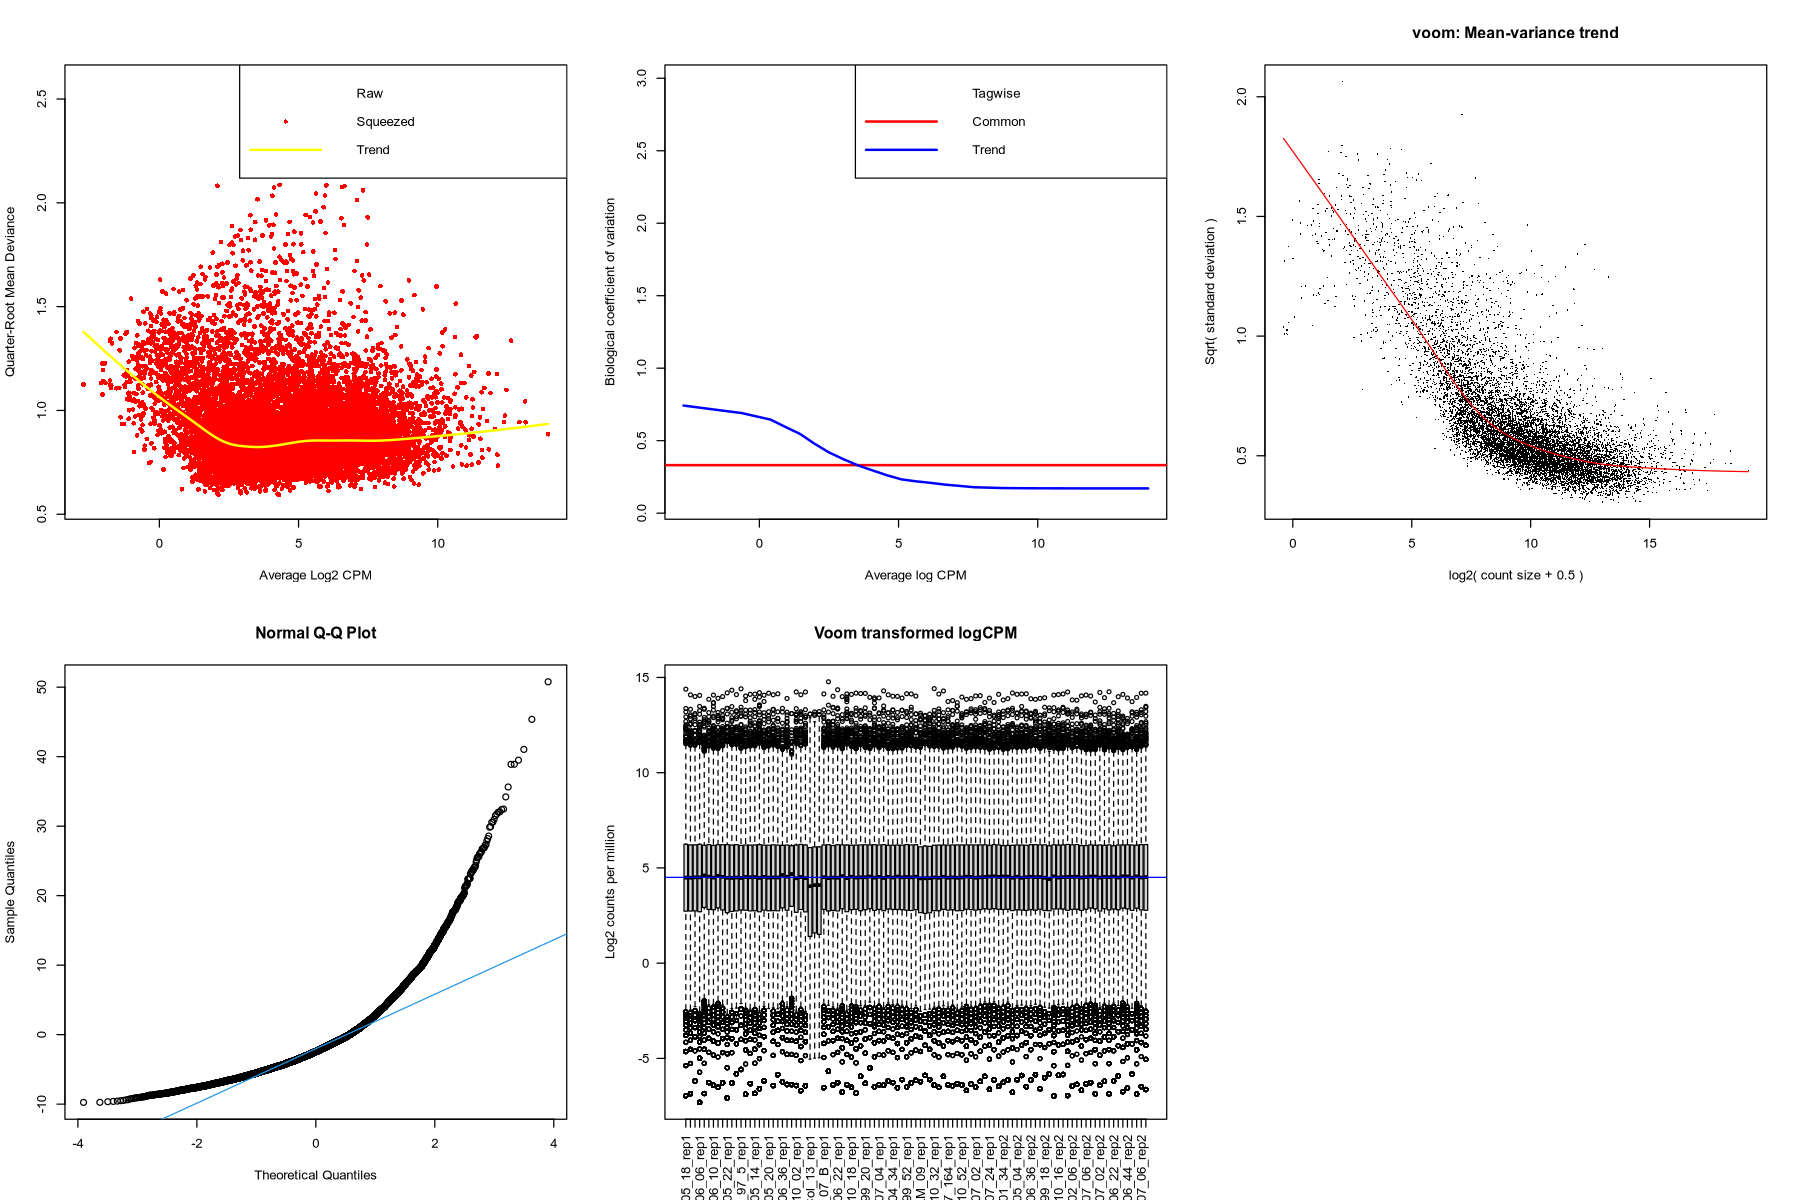

In [114]:
## create sample information data frame
reads_names <- colnames(reads) %>%
    as.data.frame()
colnames(reads_names) <- "sample"

sample_info <- reads_names %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    mutate(strain = case_when(is.na(replicate) ~ paste(locality, female, sep = "_"),
                              TRUE ~ paste(locality, female, number, sep = "_")),
           replicate = case_when(is.na(replicate) ~ number,
                                 TRUE ~ replicate))

## create design matrix 
groups <- sample_info$strain
design <- model.matrix(~0 + groups)
rownames(design) <- colnames(reads)
colnames(design) <- str_replace(colnames(design), "groups", "")

## get number of covariables (number of strains)
covariant <- length(unique(sample_info$strain))

## create DGE object
set <- newSeqExpressionSet(as.matrix(reads), phenoData = data.frame(groups, row.names = colnames(reads)))
set <- betweenLaneNormalization(set, which="upper")

y <- DGEList(counts=counts(set), group=groups)
y <- calcNormFactors(y, method="upperquartile")
y <- estimateDisp(y, design, robust = T)
fit <- glmQLFit(y, design, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)

## create new design matrix with RUVr coefficients
design_2 <- model.matrix(~ 0 + groups, data = pData(batch_ruv_res))
colnames(design_2) <- gsub("groups", "", colnames(design_2))

## create DGElist object with new design
dgeList <- DGEList(counts = reads, group = groups)
dgeList <- calcNormFactors(dgeList)
dgeList <- estimateDisp(dgeList, design_2)
dgeList_fit <- glmQLFit(dgeList, design_2, robust = TRUE)
summary(dgeList$tagwise.dispersion)


options(repr.plot.width = 15, repr.plot.height = 10)

# Use the function before each plot
par(mfrow = c(2, 3))

## QL dispersion plot
plotQLDisp(dgeList_fit, col.raw = "white", cex = 0.8, col.trend = "yellow", )

## Biological coefficient of variation
plotBCV(dgeList, col.tagwise = "white", cex = 0.8)

## Mean-variance trend
voom <- voom(dgeList, design_2, plot = TRUE)

## Goodness of fit/Q-Q plot
g.v <- gof(dgeList_fit, plot = FALSE, pcutoff = 0.05, adjust = "holm")
z.v <- zscoreGamma(g.v$gof.statistics,shape=g.v$df/2,scale=2)
qqnorm(z.v); qqline(z.v, col = 4,lwd=1,lty=1)

## normalized CPM check
boxplot(voom$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
abline(h=median(voom$E),col="blue")

In [115]:
## normalize with new design
y <- estimateDisp(y, design_2, robust = T)
fit <- glmQLFit(y, design_2, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)
RUVrNormalizedCounts <- normCounts(object = batch_ruv_res)
rownames(RUVrNormalizedCounts) <- rownames(reads)

## reformat normalized reads for saving
normalized_reads <- RUVrNormalizedCounts %>%
    as.data.frame() %>%
    rownames_to_column("gene")
head(normalized_reads)

,gene,BB_05_18_rep1,BB_05_18_rep2,BB_05_18_rep3,BU_06_06_rep1,BU_06_06_rep2,BU_06_06_rep3,BU_06_10_rep1,BU_06_10_rep2,BU_06_10_rep3,⋯,SV_07_02_rep3,WR_06_22_rep1,WR_06_22_rep2,WR_06_22_rep3,WR_06_44_rep1,WR_06_44_rep2,WR_06_44_rep3,WS_07_06_rep1,WS_07_06_rep2,WS_07_06_rep3
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,cdi,8583,8784,8738,6624,6595,6659,6446,6551,6328,⋯,7384,7539,7085,7024,7989,7339,7546,7000,7394,7385
2,mRpL55,214,228,256,254,222,261,285,311,336,⋯,306,276,294,267,405,427,405,354,346,381
3,ATPsynD,2488,2542,2837,2759,2516,2599,3015,2769,2933,⋯,3673,3335,3295,3564,3137,3587,3170,3656,3471,3797
4,sav,1203,1218,1218,775,741,772,839,806,971,⋯,1024,887,924,895,870,898,926,1261,1240,1205
5,Ctns,414,400,448,417,427,387,688,679,602,⋯,308,450,395,447,278,347,293,503,568,469
6,p53,265,251,266,324,311,313,393,389,397,⋯,243,362,277,310,385,336,391,325,366,306


In [116]:
write_tsv(normalized_reads, "intermediate/sb_dagrp_normalized_reads.tsv")

### Calculate differential expression based on fusion status

In [117]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "IR", "DI", "HI", "CF", "CI", "RB", "CB", "FP", "ML")

## determine which fixed localities have the corresponding fusion status in our strains
fixed_test <- sample_info %>% 
    inner_join(fusion, by = "strain") %>%
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed_locations)
## PG, HI, and IR in the north and RB and FP in the south

## filter for properly fixed locations
fixed <- c("PG", "IR", "HI", "RB", "FP", "ML")
trunc_sample_info <- sample_info %>% 
    inner_join(fusion, by = "strain") %>%
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed)

   
    
## calculate logfc based on fusion status for populations

## create empty logfc table to add the future log fold change data to
logfc_fixed <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_design <- model.matrix(~ trunc_groups)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_nearfixed <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fixed, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.ob

In [118]:
## count how many significant and unsignificant genes
logfc_nearfixed %>%
    group_by(significance) %>%
    count()

significance,n
<chr>,<int>
Not Significant,10587
Significant,38


In [119]:
## add location information to logfc data
logfc_nearfixed_chr <- gtf_genes %>%
    full_join(logfc_nearfixed, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_nearfixed_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

[1] 0.1454794

[1] 0.08798873

[1] 1

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


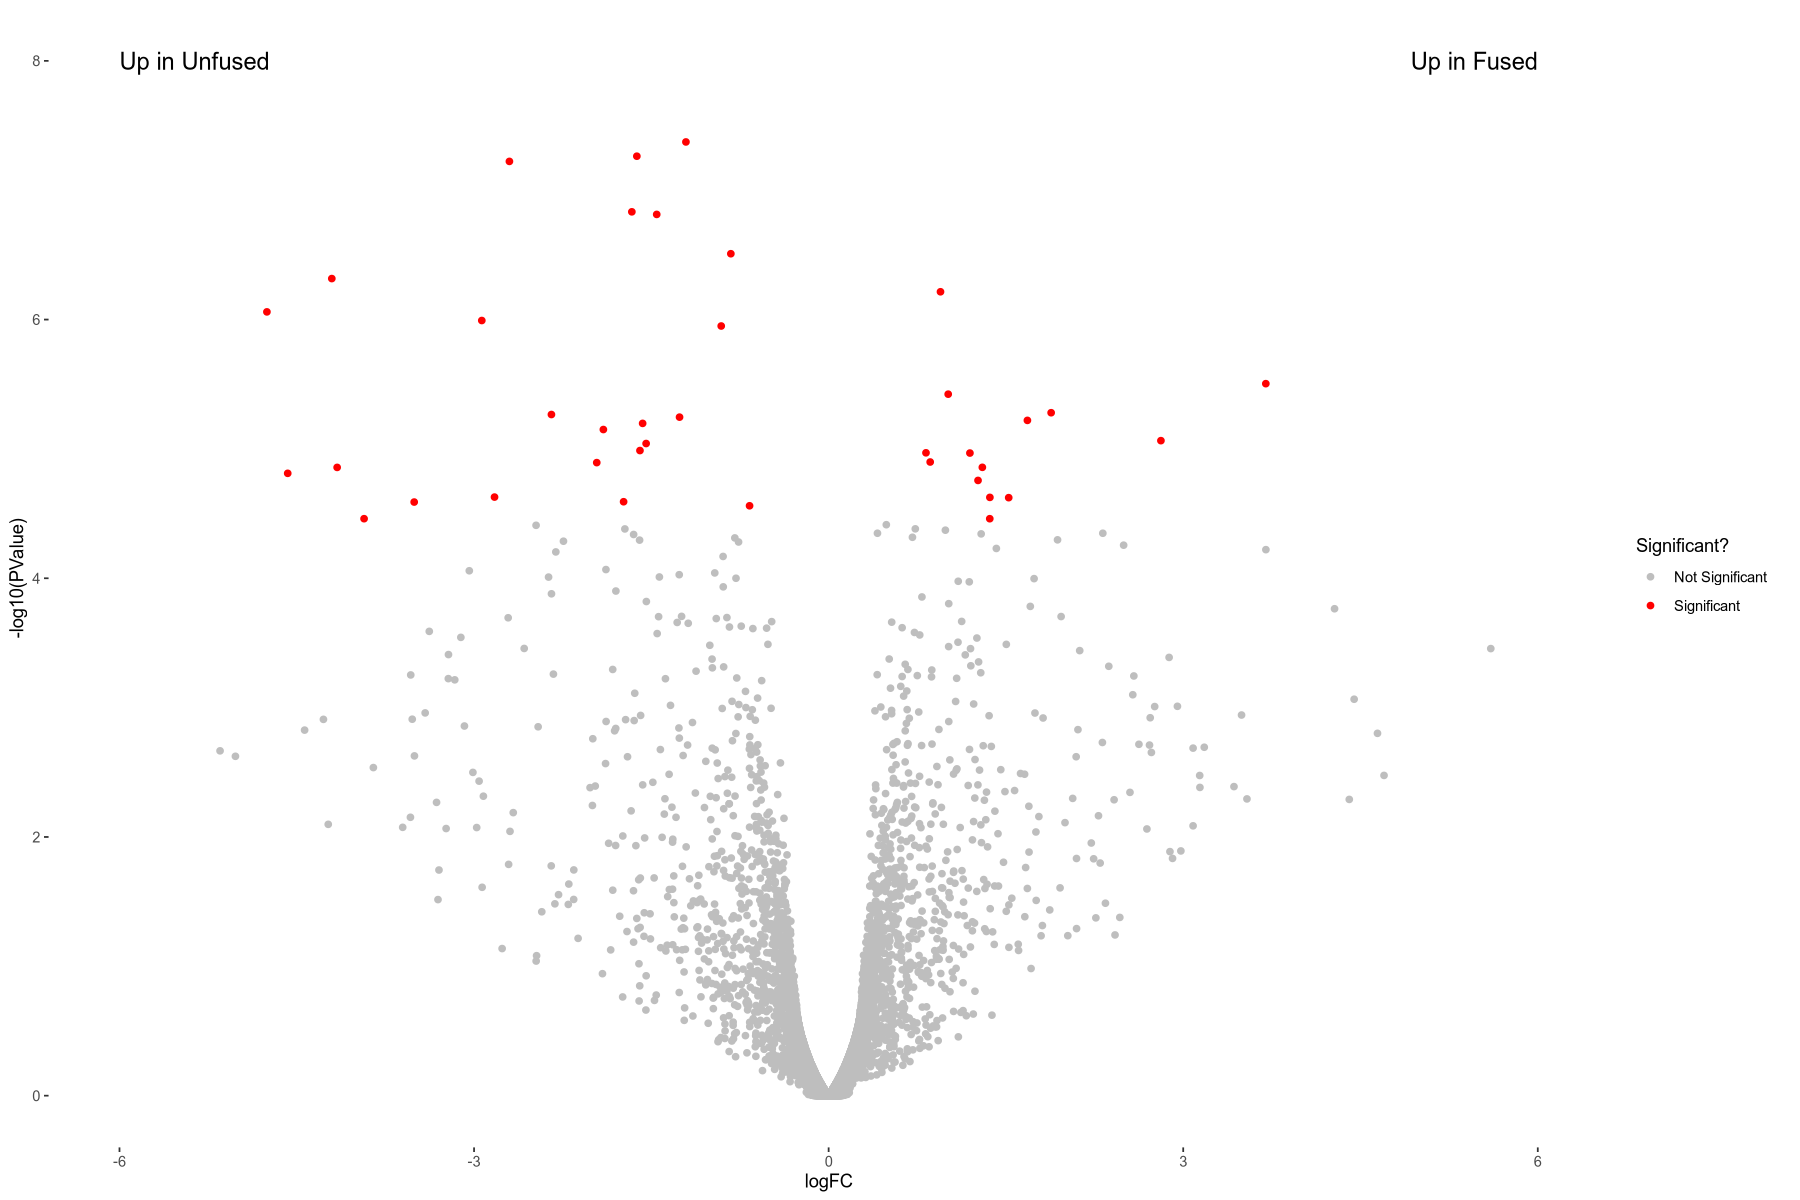

In [120]:
## plot volcano for fusion
nearfixed_volcano <- logfc_nearfixed %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        annotate("text", x = 6, y = 8, hjust = 1,
             size = 5, label = "Up in Fused") +
        annotate("text", x = -6, y = 8, hjust = 0,
             size = 5, label = "Up in Unfused")
nearfixed_volcano

In [121]:
## save plot
ggsave("figures/neoY/nearfixed_volcano.png", nearfixed_volcano)

Saving 6.67 x 6.67 in image


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


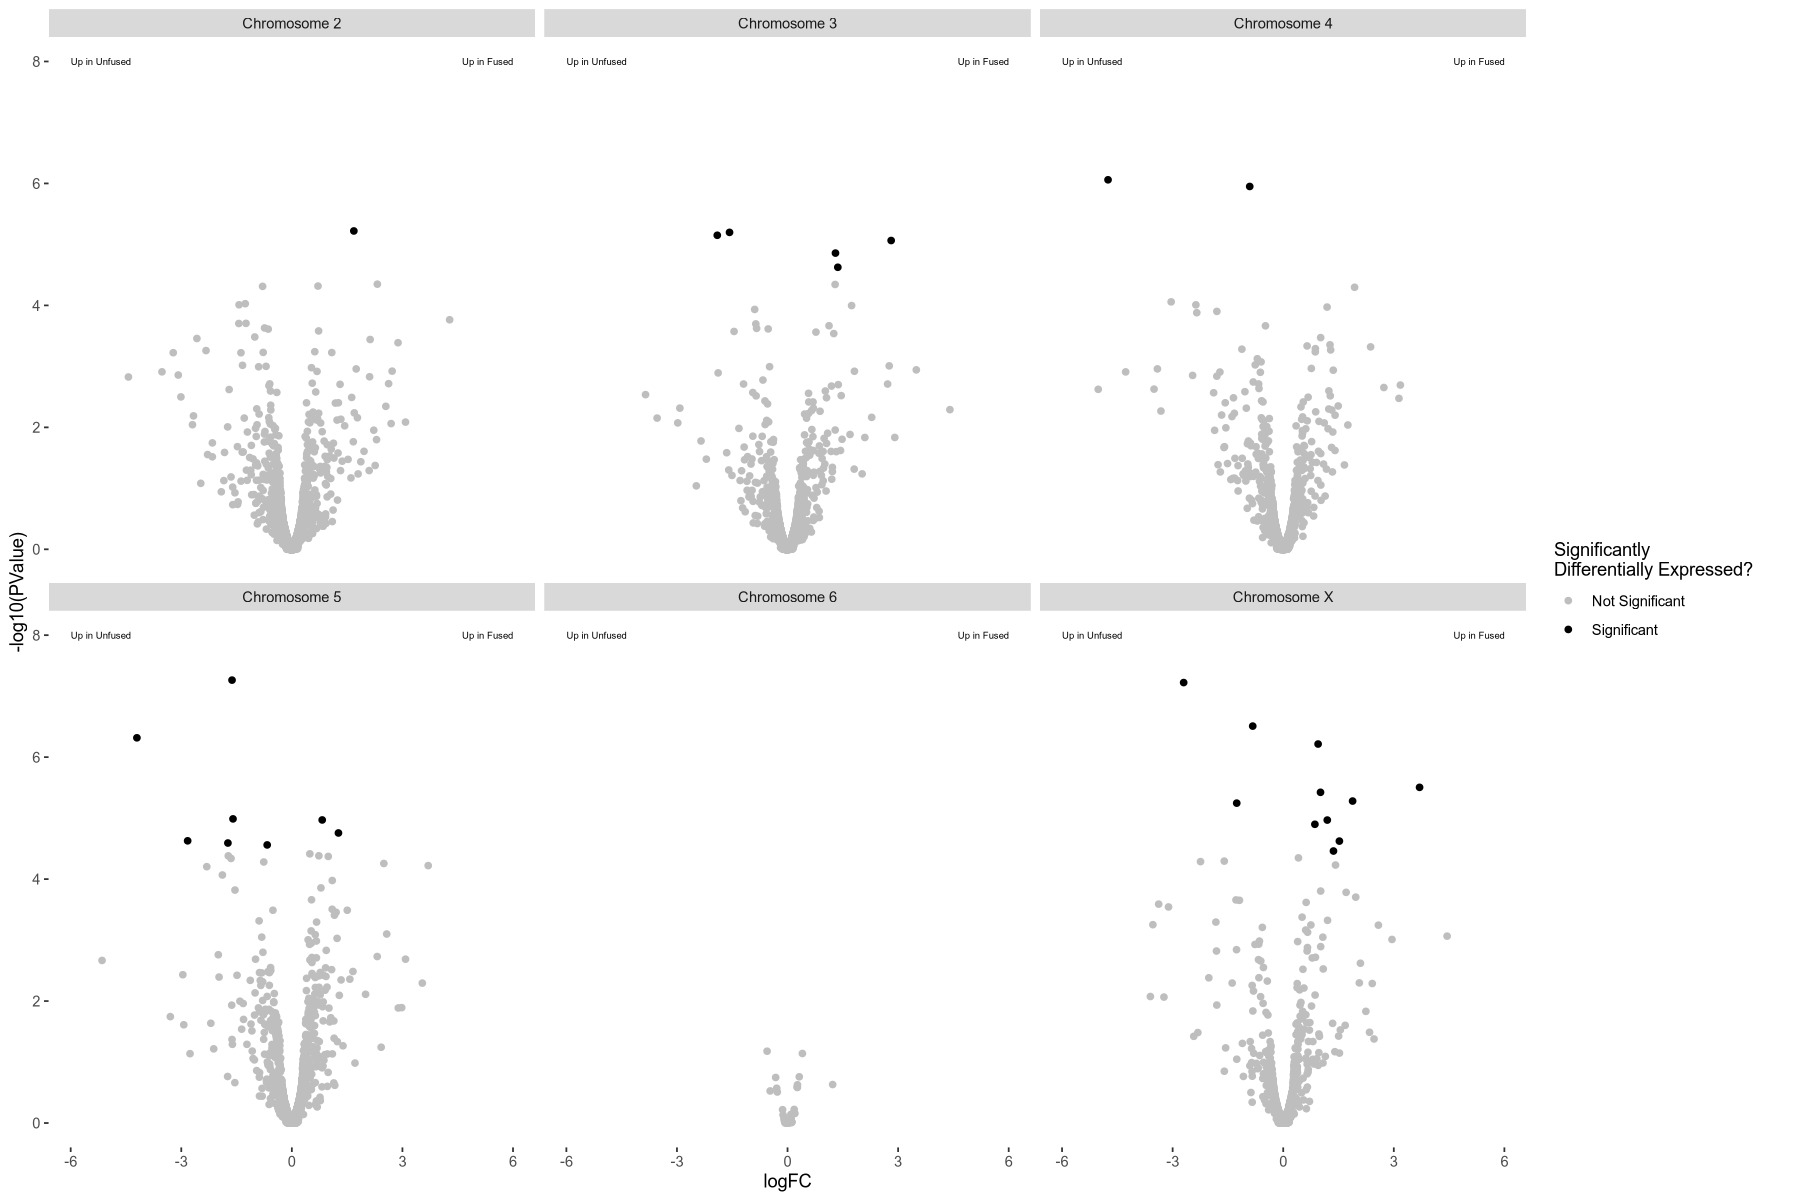

In [122]:
## plot volcano for fusion
nearfixed_chr_volcano <- logfc_nearfixed_chr %>%
    mutate(chromosome = str_replace_all(chromosome, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly\nDifferentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        annotate("text", x = 6, y = 8, hjust = 1,
             size = 2, label = "Up in Fused") +
        annotate("text", x = -6, y = 8, hjust = 0,
             size = 2, label = "Up in Unfused") +
        facet_wrap(~chromosome)
nearfixed_chr_volcano

In [123]:
## save plot
ggsave("figures/neoY/nearfixed_chr_volcano.png", nearfixed_chr_volcano, width = 12, height = 7)

### Calculate enrichment of differentially expressed genes based on having any type of mutation

### Calculate enrichment of differentially expressed genes based on having a missense/nonsense mutation

### Calculate enrichment of differentially expressed genes based on having an upstream mutation

### Calculate enrichment of differentially expressed genes per chromosome

## Investigate Motifs Upstream of Differentially Expressed Genes

### Load data

### Calculate of MSL motif is enriched in the genes upregulated in the northern fourth chromosome

## Investigate Abundance of Male Specific Genes Based on Fusion Status, Both Variance Frequency and Differential Expression

### Load data

In [131]:
## load in testes specificity calculations
tau <- read_csv("../workflow/rna/testes_specificity/results/mrt_tau_0.50.csv")
specificity <- read_csv("../workflow/rna/testes_specificity/results/testes_logfc.csv")

Rows: 13844 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): gene, max_organ, tau_tissue
dbl (2): tau, perc

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 9379 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): gene, organ
dbl (3): logfc, fdr, fdr_bh

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [132]:
## get the list of testis specific genes 
tau_genes <- tau %>%
    filter(tau_tissue == "testes") %>%
    pull("gene") %>% 
    unique()
specific_genes <- specificity$gene %>%
    unique()

## determine the overlap between genes
length(tau_genes)
length(specific_genes)
length(tau_genes[tau_genes %in% specific_genes])
length(specific_genes[specific_genes %in% tau_genes])

[1] 1725

[1] 9379

[1] 1075

[1] 1075

### Calculate enrichment of male specific genes among genes with SNPs across species

### Calculate enrichment of SNPs among male specific genes among genes based on fusion status

### Calculate enrichment of SNPs among male specific genes based on chromosome

### Calculate enrichment of male specific genes among differentially expressed genes

## Investigate Differential Chromatin Accessibility Based on Fusion Status